Test CPI extraction from sheets.  
- based on process_pngsheets.py scripts 
- source: "/home/vanessa/hulk/cocpit/processing_scripts/process_pngsheets.py"

In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random

In [2]:
print(cv2.__version__)

4.13.0


In [ ]:
# select CPI sheet
sheets_dir = Path("/home/vanessa/hulk/cocpit/cpi_data/campaigns/AIRS_II/sheets")

specified_file = "2003_1112_004322_145.png"  # or None for random

files = [f for f in sheets_dir.iterdir() if f.is_file()]

selected_file = (
    sheets_dir / specified_file
    if specified_file
    else random.choice(files)
)

print(selected_file.name)
print(selected_file)

In [ ]:
# visualize the sheet 
# Read image with OpenCV
img = cv2.imread(str(rand_file))

# crop the header 
height, width, channels = img.shape
img_cropped = img[25:height, 0:width]

# Convert BGR -> grayscale
img_gray = cv2.cvtColor(img_cropped, cv2.COLOR_BGR2GRAY)

# Convert BGR -> RGB
img_rgb = cv2.cvtColor(img_cropped, cv2.COLOR_BGR2RGB)

In [ ]:
# Plot RGB
plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(rand_file.name)
plt.show()

In [ ]:
# Plot grayscale 
plt.figure(figsize=(12, 12))
plt.imshow(img_gray, cmap='gray')
plt.axis("off")
plt.title(rand_file.name)
plt.show()

Is there information lost when converting to grayscale?   
--> No. Double checked online to confirm that CCD array captures single channel information. The blue colored hue is artificial. 

In [ ]:
# calculate threshold 
thresh = cv2.threshold(img_gray, 225, 225, cv2.THRESH_BINARY_INV)[1]

In [ ]:
# get contours and visualize 
(cnts, _) = cv2.findContours(
    thresh.copy(), 
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
    )

In [ ]:
len(cnts)

In [ ]:
# save each cropped image 
for i, c in enumerate(cnts):
    rect = cv2.boundingRect(c)
    x, y, w, h = rect
    cropped = img_gray[y:y+h, x:x+w]
    save_dir = "../data/test_process_pngsheets/"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"{rand_file.name[:-4]}_{i}.png")
    cv2.imwrite(save_path, cropped)

Method used in COCPIT results in 70 estimate contours (for 2003_1112_004322_145.png), which is much more than the number of crystals clearly on the sheet! From manually counting there are 21 crystals.

Try alternative method suggested by ChatGPT: https://chatgpt.com/s/t_6a01f4fa974c819182eb6dde28a0b4cd

In [ ]:
# examine intensity histogram
plt.hist(img_gray.ravel(), bins=256)
plt.xlabel("Pixel intensity")
plt.ylabel("Count")
plt.show()

In [ ]:
# estimate threshold with Otsu thresholding
# reference: https://en.wikipedia.org/wiki/Otsu%27s_method
thresh, mask = cv2.threshold(
    img_gray,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print(thresh)

In [ ]:
# get mask, crystals are dark
mask = img_gray < thresh

In [ ]:
# # clean mask
# mask = morphology.remove_small_objects(mask, 50)
# mask = morphology.remove_small_holes(mask, 50)

In [ ]:
# get connected components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    mask.astype(np.uint8),
    connectivity=8
)

In [ ]:
import cv2
import matplotlib.pyplot as plt

vis = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)

for i in range(1, num_labels):  # skip background label 0
    x, y, w, h, area = stats[i]

    # filter tiny noise
    if area < 50:
        continue

    cv2.rectangle(vis, (x, y), (x+w, y+h), (0,255,0), 2)

plt.figure(figsize=(12,12))
plt.imshow(vis)
plt.axis("off")
plt.show()

# Alternative 1: Dynamic header removal

In [ ]:
# select CPI sheet
sheets_dir = Path("/home/vanessa/hulk/cocpit/cpi_data/campaigns/AIRS_II/sheets")

specified_file = "2003_1112_004322_145.png"  # or None for random

files = [f for f in sheets_dir.iterdir() if f.is_file()]

selected_file = (
    sheets_dir / specified_file
    if specified_file
    else random.choice(files)
)

print(selected_file.name)
print(selected_file)

In [ ]:
# Read image with OpenCV
img = cv2.imread(str(rand_file))

# Convert BGR -> grayscale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [ ]:
# estimate threshold with Otsu thresholding
# reference: https://en.wikipedia.org/wiki/Otsu%27s_method
thresh, mask = cv2.threshold(
    img_gray,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print(thresh)

In [ ]:
# ---------------------------------------------------------
# Automatically detect top header height
# with more aggressive text suppression
# ---------------------------------------------------------

# ---------------------------------------------------------
# Step 1: Remove tiny text-like structures
# ---------------------------------------------------------

# Larger horizontal kernel removes small header text
# while preserving large montage regions
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (45, 7)
)

mask_clean = cv2.morphologyEx(
    mask,
    cv2.MORPH_OPEN,
    kernel
)

# ---------------------------------------------------------
# Step 2: Foreground pixel count per row
# ---------------------------------------------------------

row_counts = (mask_clean > 0).sum(axis=1)

# ---------------------------------------------------------
# Step 3: Smooth row-density signal
# ---------------------------------------------------------

smooth_kernel = np.ones(15) / 15

row_counts_smooth = np.convolve(
    row_counts,
    smooth_kernel,
    mode='same'
)

# ---------------------------------------------------------
# Step 4: Detect montage start robustly
# ---------------------------------------------------------

height, width = img_gray.shape

density_threshold = 0.15 * width

above_threshold = row_counts_smooth > density_threshold

# Require sustained foreground density
window = 8

header_end_row = None

for i in range(len(above_threshold) - window):

    if np.all(above_threshold[i:i+window]):
        # shift slightly downward to avoid clipping text
        header_end_row = i + 3
        break

# fallback
if header_end_row is None:
    header_end_row = 0

print(f"Detected header height: {header_end_row} pixels")

# ---------------------------------------------------------
# Step 5: Crop image automatically
# ---------------------------------------------------------

img_cropped = img[header_end_row:, :]
gray_cropped = img_gray[header_end_row:, :]
mask_cropped = mask[header_end_row:, :]

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# ---------------------------------------------------------
# Left panel: first 100 foreground counts as points only
# ---------------------------------------------------------

rows = np.arange(min(100, len(row_counts)))

ax[0].scatter(
    rows,
    row_counts[:100],
    s=12,
    alpha=0.8
)

ax[0].axvline(
    header_end_row,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Header End = {header_end_row}'
)

ax[0].axhline(
    density_threshold,
    color='green',
    linestyle=':',
    linewidth=2,
    label=f'Threshold = {density_threshold:.1f}'
)

ax[0].set_title("Foreground Pixel Count Per Row (First 100 Rows)")
ax[0].set_xlabel("Row Index")
ax[0].set_ylabel("Foreground Pixel Count")

ax[0].legend()

# ---------------------------------------------------------
# Right panel: cropped image
# ---------------------------------------------------------

ax[1].imshow(gray_cropped, cmap='gray')

ax[1].set_title(
    f"Automatically Cropped Image\n"
    f"Removed Top {header_end_row} Rows"
)

ax[1].axis('off')

plt.tight_layout()
plt.show()

## Test on more sheets

In [ ]:
from pathlib import Path
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

sheets_dir = Path(
    "/home/vanessa/hulk/cocpit/cpi_data/campaigns/AIRS_II/sheets"
)

output_dir = Path("../figs/header_threshold_test")
output_dir.mkdir(parents=True, exist_ok=True)

N_sheets = 10  # number of random sheets to process

# ---------------------------------------------------------
# Gather files
# ---------------------------------------------------------

files = [f for f in sheets_dir.iterdir() if f.is_file()]

if len(files) == 0:
    raise RuntimeError("No files found in sheets directory.")

N_sheets = min(N_sheets, len(files))

selected_files = random.sample(files, N_sheets)

print(f"Processing {N_sheets} random sheets...")
print()

# ---------------------------------------------------------
# Process each sheet
# ---------------------------------------------------------

for idx, selected_file in enumerate(selected_files):

    print("=" * 60)
    print(f"[{idx+1}/{N_sheets}] {selected_file.name}")

    # ---------------------------------------------------------
    # Read image
    # ---------------------------------------------------------

    img = cv2.imread(str(selected_file))

    if img is None:
        print("Failed to load image.")
        continue

    # Convert BGR -> grayscale
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ---------------------------------------------------------
    # Otsu threshold
    # ---------------------------------------------------------

    thresh, mask = cv2.threshold(
        img_gray,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    print(f"Otsu threshold: {thresh:.2f}")

    # ---------------------------------------------------------
    # Step 1: Remove tiny text-like structures
    # ---------------------------------------------------------

    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (45, 7)
    )

    mask_clean = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel
    )

    # ---------------------------------------------------------
    # Step 2: Foreground pixel count per row
    # ---------------------------------------------------------

    row_counts = (mask_clean > 0).sum(axis=1)

    # ---------------------------------------------------------
    # Step 3: Smooth row-density signal
    # ---------------------------------------------------------

    smooth_kernel = np.ones(15) / 15

    row_counts_smooth = np.convolve(
        row_counts,
        smooth_kernel,
        mode='same'
    )

    # ---------------------------------------------------------
    # Step 4: Detect montage start robustly
    # ---------------------------------------------------------

    height, width = img_gray.shape

    density_threshold = 0.15 * width

    above_threshold = row_counts_smooth > density_threshold

    window = 8

    header_end_row = None

    for i in range(len(above_threshold) - window):

        if np.all(above_threshold[i:i+window]):
            header_end_row = i + 3
            break

    # fallback
    if header_end_row is None:
        header_end_row = 0

    print(f"Detected header height: {header_end_row} pixels")

    # ---------------------------------------------------------
    # Step 5: Crop image automatically
    # ---------------------------------------------------------

    gray_cropped = img_gray[header_end_row:, :]

    # ---------------------------------------------------------
    # Visualization
    # ---------------------------------------------------------

    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    # ---------------------------------------------------------
    # Left panel: foreground counts
    # ---------------------------------------------------------

    max_rows_plot = min(150, len(row_counts))

    rows = np.arange(max_rows_plot)

    ax[0].scatter(
        rows,
        row_counts[:max_rows_plot],
        s=12,
        alpha=0.8,
        label="Raw Counts"
    )

    ax[0].plot(
        rows,
        row_counts_smooth[:max_rows_plot],
        linewidth=2,
        label="Smoothed"
    )

    ax[0].axvline(
        header_end_row,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Header End = {header_end_row}'
    )

    ax[0].axhline(
        density_threshold,
        color='green',
        linestyle=':',
        linewidth=2,
        label=f'Threshold = {density_threshold:.1f}'
    )

    ax[0].set_title(
        "Foreground Pixel Count Per Row\n"
        f"{selected_file.name}"
    )

    ax[0].set_xlabel("Row Index")
    ax[0].set_ylabel("Foreground Pixel Count")

    ax[0].legend()

    # ---------------------------------------------------------
    # Right panel: cropped image
    # ---------------------------------------------------------

    ax[1].imshow(gray_cropped, cmap='gray')

    ax[1].set_title(
        f"Automatically Cropped Image\n"
        f"Removed Top {header_end_row} Rows"
    )

    ax[1].axis('off')

    plt.tight_layout()

    # ---------------------------------------------------------
    # Save figure
    # ---------------------------------------------------------

    save_path = output_dir / f"{selected_file.stem}_diagnostic.png"

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches='tight'
    )

    plt.close(fig)

    print(f"Saved diagnostic plot:")
    print(save_path)
    print()

print("=" * 60)
print("Done.")

# Alternative 2: Segment first, remove text if necessary

In [ ]:
from pathlib import Path
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Configuration
# =========================================================

sheets_dir = Path(
    "/home/vanessa/hulk/cocpit/cpi_data/campaigns/ATTREX/sheets"
)

output_dir = Path("../figs/simple_segment_test_attrex")
output_dir.mkdir(parents=True, exist_ok=True)

N_sheets = 10

# ---------------------------------------------------------
# Simple segmentation parameters
# ---------------------------------------------------------

HEADER_CROP = 25

WHITE_THRESHOLD = 245

MIN_WIDTH = 12
MIN_HEIGHT = 12

MAX_ASPECT = 8
MIN_ASPECT = 1 / MAX_ASPECT

# =========================================================
# Gather files
# =========================================================

files = [f for f in sheets_dir.iterdir() if f.is_file()]

if len(files) == 0:
    raise RuntimeError("No files found.")

N_sheets = min(N_sheets, len(files))

selected_files = random.sample(files, N_sheets)

print(f"Processing {N_sheets} random sheets...")
print()

# =========================================================
# Main loop
# =========================================================

for idx, selected_file in enumerate(selected_files):

    print("=" * 60)
    print(f"[{idx+1}/{N_sheets}] {selected_file.name}")

    # -----------------------------------------------------
    # Read image
    # -----------------------------------------------------

    img = cv2.imread(str(selected_file))

    if img is None:
        print("Failed to load image.")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # -----------------------------------------------------
    # Remove top header region
    # -----------------------------------------------------

    gray = gray[HEADER_CROP:, :]
    img = img[HEADER_CROP:, :]

    # -----------------------------------------------------
    # Detect non-white pixels
    # -----------------------------------------------------

    # Anything darker than near-white becomes foreground
    mask = gray < WHITE_THRESHOLD

    mask = mask.astype(np.uint8) * 255

    # -----------------------------------------------------
    # Connected components
    # -----------------------------------------------------

    num_labels, labels, stats, centroids = \
        cv2.connectedComponentsWithStats(mask)

    boxes = []

    for i in range(1, num_labels):

        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]

        # -------------------------------------------------
        # Reject tiny components
        # -------------------------------------------------

        if w < MIN_WIDTH or h < MIN_HEIGHT:
            continue

        # -------------------------------------------------
        # Reject extreme aspect ratios
        # -------------------------------------------------

        aspect = w / h

        if aspect > MAX_ASPECT or aspect < MIN_ASPECT:
            continue

        boxes.append((x, y, w, h))

    print(f"Detected {len(boxes)} boxes")

    # -----------------------------------------------------
    # Visualization
    # -----------------------------------------------------

    overlay = img.copy()

    for (x, y, w, h) in boxes:

        cv2.rectangle(
            overlay,
            (x, y),
            (x + w, y + h),
            (0, 0, 255),
            2
        )

    # -----------------------------------------------------
    # Plot diagnostics
    # -----------------------------------------------------

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    # Original
    ax[0].imshow(gray, cmap='gray')
    ax[0].set_title("Cropped Grayscale")
    ax[0].axis('off')

    # Mask
    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title("Non-White Mask")
    ax[1].axis('off')

    # Bounding boxes
    ax[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax[2].set_title(f"Detected Crystal Tiles\nN = {len(boxes)}")
    ax[2].axis('off')

    plt.tight_layout()

    # -----------------------------------------------------
    # Save figure
    # -----------------------------------------------------

    save_path = output_dir / (
        f"{selected_file.stem}_diagnostic.png"
    )

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches='tight'
    )

    plt.close(fig)

    print(f"Saved:")
    print(save_path)
    print()

print("=" * 60)
print("Done.")

# Alternative 3: Modifed alt2 + removing text with contours

In [ ]:
from pathlib import Path
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Configuration
# =========================================================

sheets_dir = Path(
    "/home/vanessa/hulk/cocpit/cpi_data/campaigns/ATTREX/sheets"
)

output_dir = Path("../figs/segment_alt_3_test_attrex")
output_dir.mkdir(parents=True, exist_ok=True)

N_sheets = 10

# ---------------------------------------------------------
# Simple segmentation parameters
# ---------------------------------------------------------

HEADER_CROP = 25

WHITE_THRESHOLD = 180 # adjust, lower is darker threshold

MIN_WIDTH = 12
MIN_HEIGHT = 12

MAX_ASPECT = 8
MIN_ASPECT = 1 / MAX_ASPECT

# Local contour refinement
LOCAL_THRESH = 200

# =========================================================
# Gather files
# =========================================================

files = [f for f in sheets_dir.iterdir() if f.is_file()]

if len(files) == 0:
    raise RuntimeError("No files found.")

N_sheets = min(N_sheets, len(files))

selected_files = random.sample(files, N_sheets)

print(f"Processing {N_sheets} random sheets...")
print()

# =========================================================
# Main loop
# =========================================================

for idx, selected_file in enumerate(selected_files):

    print("=" * 60)
    print(f"[{idx+1}/{N_sheets}] {selected_file.name}")

    # -----------------------------------------------------
    # Read image
    # -----------------------------------------------------

    img = cv2.imread(str(selected_file))

    if img is None:
        print("Failed to load image.")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # -----------------------------------------------------
    # Remove top header region
    # -----------------------------------------------------

    gray = gray[HEADER_CROP:, :]
    img = img[HEADER_CROP:, :]

    # -----------------------------------------------------
    # Detect non-white pixels
    # -----------------------------------------------------

    mask = gray < WHITE_THRESHOLD

    mask = mask.astype(np.uint8) * 255

    # -----------------------------------------------------
    # Connected components
    # -----------------------------------------------------

    num_labels, labels, stats, centroids = \
        cv2.connectedComponentsWithStats(mask)

    boxes = []

    # =====================================================
    # Candidate components
    # =====================================================

    for i in range(1, num_labels):

        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]

        # -------------------------------------------------
        # Reject tiny components
        # -------------------------------------------------

        if w < MIN_WIDTH or h < MIN_HEIGHT:
            continue

        # -------------------------------------------------
        # Reject extreme aspect ratios
        # -------------------------------------------------

        aspect = w / h

        if aspect > MAX_ASPECT or aspect < MIN_ASPECT:
            continue

        # =================================================
        # Local contour refinement
        # =================================================

        patch_gray = gray[y:y+h, x:x+w]

        # Threshold local patch
        _, patch_binary = cv2.threshold(
            patch_gray,
            LOCAL_THRESH,
            255,
            cv2.THRESH_BINARY_INV
        )

        # Find contours
        contours, _ = cv2.findContours(
            patch_binary,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        if len(contours) == 0:
            continue

        # Largest contour
        largest_contour = max(
            contours,
            key=cv2.contourArea
        )

        # Bounding box of largest contour
        cx, cy, cw, ch = cv2.boundingRect(
            largest_contour
        )

        # Reject tiny refined contours
        if cw < 6 or ch < 6:
            continue

        # Convert back to global coordinates
        refined_box = (
            x + cx,
            y + cy,
            cw,
            ch
        )

        boxes.append(refined_box)

    print(f"Detected {len(boxes)} refined boxes")

    # -----------------------------------------------------
    # Visualization
    # -----------------------------------------------------

    overlay = img.copy()

    for (x, y, w, h) in boxes:

        cv2.rectangle(
            overlay,
            (x, y),
            (x + w, y + h),
            (0, 0, 255),
            2
        )

    # -----------------------------------------------------
    # Plot diagnostics
    # -----------------------------------------------------

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    # Original
    ax[0].imshow(gray, cmap='gray')
    ax[0].set_title("Cropped Grayscale")
    ax[0].axis('off')

    # Mask
    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title("Non-White Mask")
    ax[1].axis('off')

    # Bounding boxes
    ax[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax[2].set_title(
        f"Refined Crystal Bounding Boxes\nN = {len(boxes)}"
    )
    ax[2].axis('off')

    plt.tight_layout()

    # -----------------------------------------------------
    # Save figure
    # -----------------------------------------------------

    save_path = output_dir / (
        f"{selected_file.stem}_diagnostic.png"
    )

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches='tight'
    )

    plt.close(fig)

    print(f"Saved:")
    print(save_path)
    print()

print("=" * 60)
print("Done.")

# Alternative 4: pytesseract (remove text with ocr) + segment

In [ ]:
from pathlib import Path
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract

# =========================================================
# Configuration
# =========================================================

sheets_dir = Path(
    "/home/vanessa/hulk/cocpit/cpi_data/campaigns/ATTREX/sheets"
)

output_dir = Path("../figs/segment_alt_4_tesseract_test_attrex")
output_dir.mkdir(parents=True, exist_ok=True)

N_sheets = 10

# =========================================================
# Segmentation parameters
# =========================================================

HEADER_CROP = 25

# Lower = stricter / darker-only segmentation
WHITE_THRESHOLD = 180

MIN_WIDTH = 12
MIN_HEIGHT = 12

MAX_ASPECT = 8
MIN_ASPECT = 1 / MAX_ASPECT

# OCR parameters
OCR_CONFIDENCE = 40

OCR_PAD = 2

TESSERACT_CONFIG = "--psm 11"

# =========================================================
# Gather files
# =========================================================

files = [f for f in sheets_dir.iterdir() if f.is_file()]

if len(files) == 0:
    raise RuntimeError("No files found.")

N_sheets = min(N_sheets, len(files))

selected_files = random.sample(files, N_sheets)

print(f"Processing {N_sheets} random sheets...")
print()

# =========================================================
# Main loop
# =========================================================

for idx, selected_file in enumerate(selected_files):

    print("=" * 60)
    print(f"[{idx+1}/{N_sheets}] {selected_file.name}")

    # -----------------------------------------------------
    # Read image
    # -----------------------------------------------------

    img = cv2.imread(str(selected_file))

    if img is None:
        print("Failed to load image.")
        continue

    gray_original = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # -----------------------------------------------------
    # Remove top header region
    # -----------------------------------------------------

    gray = gray_original[HEADER_CROP:, :].copy()

    img = img[HEADER_CROP:, :]

    # =====================================================
    # OCR TEXT DETECTION + REMOVAL
    # =====================================================

    gray_text_removed = gray.copy()

    ocr_data = pytesseract.image_to_data(
        gray,
        output_type=pytesseract.Output.DICT,
        config=TESSERACT_CONFIG
    )

    n_boxes = len(ocr_data["text"])

    removed_text_boxes = []

    for i in range(n_boxes):

        text = ocr_data["text"][i].strip()

        try:
            conf = float(ocr_data["conf"][i])
        except:
            conf = -1

        # -------------------------------------------------
        # Skip low-confidence detections
        # -------------------------------------------------

        if conf < OCR_CONFIDENCE:
            continue

        # Ignore empty detections
        if text == "":
            continue

        x = ocr_data["left"][i]
        y = ocr_data["top"][i]
        w = ocr_data["width"][i]
        h = ocr_data["height"][i]

        # -------------------------------------------------
        # Expand box slightly
        # -------------------------------------------------

        x1 = max(0, x - OCR_PAD)
        y1 = max(0, y - OCR_PAD)

        x2 = min(gray.shape[1], x + w + OCR_PAD)
        y2 = min(gray.shape[0], y + h + OCR_PAD)

        # -------------------------------------------------
        # Remove text by whitening region
        # -------------------------------------------------

        gray_text_removed[y1:y2, x1:x2] = 255

        removed_text_boxes.append((x1, y1, x2-x1, y2-y1))

    print(f"Removed {len(removed_text_boxes)} OCR text regions")

    # =====================================================
    # Segmentation
    # =====================================================

    mask = gray_text_removed < WHITE_THRESHOLD

    mask = mask.astype(np.uint8) * 255

    # Small morphology cleanup
    kernel = np.ones((2,2), np.uint8)

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel
    )

    # =====================================================
    # Connected components
    # =====================================================

    num_labels, labels, stats, centroids = \
        cv2.connectedComponentsWithStats(mask)

    boxes = []

    for i in range(1, num_labels):

        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]

        # -------------------------------------------------
        # Reject tiny components
        # -------------------------------------------------

        if w < MIN_WIDTH or h < MIN_HEIGHT:
            continue

        # -------------------------------------------------
        # Reject extreme aspect ratios
        # -------------------------------------------------

        aspect = w / h

        if aspect > MAX_ASPECT or aspect < MIN_ASPECT:
            continue

        boxes.append((x, y, w, h))

    print(f"Detected {len(boxes)} crystal boxes")

    # =====================================================
    # Visualization
    # =====================================================

    overlay = img.copy()

    # Draw OCR boxes in blue
    for (x, y, w, h) in removed_text_boxes:

        cv2.rectangle(
            overlay,
            (x, y),
            (x+w, y+h),
            (255, 0, 0),
            1
        )

    # Draw crystal boxes in red
    for (x, y, w, h) in boxes:

        cv2.rectangle(
            overlay,
            (x, y),
            (x+w, y+h),
            (0, 0, 255),
            2
        )

    # =====================================================
    # Plot diagnostics
    # =====================================================

    fig, ax = plt.subplots(1, 4, figsize=(24, 6))

    # Original
    ax[0].imshow(gray, cmap='gray')
    ax[0].set_title("Original Grayscale")
    ax[0].axis('off')

    # OCR-cleaned image
    ax[1].imshow(gray_text_removed, cmap='gray')
    ax[1].set_title("After OCR Text Removal")
    ax[1].axis('off')

    # Binary mask
    ax[2].imshow(mask, cmap='gray')
    ax[2].set_title("Segmentation Mask")
    ax[2].axis('off')

    # Final detections
    ax[3].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax[3].set_title(
        f"Final Crystal Bounding Boxes\nN = {len(boxes)}"
    )
    ax[3].axis('off')

    plt.tight_layout()

    # =====================================================
    # Save figure
    # =====================================================

    save_path = output_dir / (
        f"{selected_file.stem}_diagnostic.png"
    )

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches='tight'
    )

    plt.close(fig)

    print(f"Saved:")
    print(save_path)
    print()

print("=" * 60)
print("Done.")

# Alternative 5: OpenCV only, morphology based

In [ ]:
from pathlib import Path
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Configuration
# =========================================================

sheets_dir = Path(
    "/home/vanessa/hulk/cocpit/cpi_data/campaigns/ATTREX/sheets"
)

output_dir = Path("../figs/segment_alt_5_morphology_test_attrex")
output_dir.mkdir(parents=True, exist_ok=True)

N_sheets = 10

# =========================================================
# Segmentation parameters
# =========================================================

HEADER_CROP = 25

# Lower than before to avoid faint text/noise
WHITE_THRESHOLD = 220

MIN_WIDTH = 12
MIN_HEIGHT = 12

MAX_ASPECT = 8
MIN_ASPECT = 1 / MAX_ASPECT

# =========================================================
# Gather files
# =========================================================

files = [f for f in sheets_dir.iterdir() if f.is_file()]

if len(files) == 0:
    raise RuntimeError("No files found.")

N_sheets = min(N_sheets, len(files))

selected_files = random.sample(files, N_sheets)

print(f"Processing {N_sheets} random sheets...")
print()

# =========================================================
# Main loop
# =========================================================

for idx, selected_file in enumerate(selected_files):

    print("=" * 60)
    print(f"[{idx+1}/{N_sheets}] {selected_file.name}")

    # -----------------------------------------------------
    # Read image
    # -----------------------------------------------------

    img = cv2.imread(str(selected_file))

    if img is None:
        print("Failed to load image.")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # -----------------------------------------------------
    # Remove header
    # -----------------------------------------------------

    gray = gray[HEADER_CROP:, :]
    img = img[HEADER_CROP:, :]

    # =====================================================
    # STEP 1:
    # Threshold foreground
    # =====================================================

    _, mask = cv2.threshold(
        gray,
        WHITE_THRESHOLD,
        255,
        cv2.THRESH_BINARY_INV
    )

    # =====================================================
    # STEP 2:
    # Remove thin timestamp text
    # =====================================================

    erode_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3)
    )

    mask_eroded = cv2.erode(
        mask,
        erode_kernel,
        iterations=1
    )

    # =====================================================
    # STEP 3:
    # Restore crystal blobs
    # =====================================================

    dilate_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5, 5)
    )

    mask_clean = cv2.dilate(
        mask_eroded,
        dilate_kernel,
        iterations=1
    )

    # =====================================================
    # STEP 4:
    # Additional cleanup
    # =====================================================

    open_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3)
    )

    mask_clean = cv2.morphologyEx(
        mask_clean,
        cv2.MORPH_OPEN,
        open_kernel
    )

    # =====================================================
    # STEP 5:
    # Connected components
    # =====================================================

    num_labels, labels, stats, centroids = \
        cv2.connectedComponentsWithStats(mask_clean)

    boxes = []

    overlay = img.copy()

    # =====================================================
    # STEP 6:
    # Refine each component using largest contour
    # =====================================================

    for i in range(1, num_labels):

        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]

        # -------------------------------------------------
        # Reject tiny regions
        # -------------------------------------------------

        if w < MIN_WIDTH or h < MIN_HEIGHT:
            continue

        # -------------------------------------------------
        # Reject extreme aspect ratios
        # -------------------------------------------------

        aspect = w / h

        if aspect > MAX_ASPECT or aspect < MIN_ASPECT:
            continue

        # -------------------------------------------------
        # Extract local component region
        # -------------------------------------------------

        local_mask = mask_clean[y:y+h, x:x+w]

        contours, _ = cv2.findContours(
            local_mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        if len(contours) == 0:
            continue

        # -------------------------------------------------
        # Keep largest contour only
        # -------------------------------------------------

        largest = max(contours, key=cv2.contourArea)

        area = cv2.contourArea(largest)

        # Reject tiny leftover contours
        if area < 25:
            continue

        # -------------------------------------------------
        # Refined bounding box
        # -------------------------------------------------

        rx, ry, rw, rh = cv2.boundingRect(largest)

        final_x = x + rx
        final_y = y + ry
        final_w = rw
        final_h = rh

        # -------------------------------------------------
        # Final sanity checks
        # -------------------------------------------------

        final_aspect = final_w / final_h

        if final_aspect > MAX_ASPECT \
           or final_aspect < MIN_ASPECT:
            continue

        if final_w < MIN_WIDTH \
           or final_h < MIN_HEIGHT:
            continue

        boxes.append(
            (final_x, final_y, final_w, final_h)
        )

    print(f"Detected {len(boxes)} boxes")

    # =====================================================
    # Draw boxes
    # =====================================================

    for (x, y, w, h) in boxes:

        cv2.rectangle(
            overlay,
            (x, y),
            (x + w, y + h),
            (0, 0, 255),
            2
        )

    # =====================================================
    # Plot diagnostics
    # =====================================================

    fig, ax = plt.subplots(
        1,
        4,
        figsize=(24, 6)
    )

    # -----------------------------------------------------
    # Original
    # -----------------------------------------------------

    ax[0].imshow(gray, cmap='gray')
    ax[0].set_title("Original Grayscale")
    ax[0].axis('off')

    # -----------------------------------------------------
    # Initial threshold
    # -----------------------------------------------------

    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title("Initial Threshold")
    ax[1].axis('off')

    # -----------------------------------------------------
    # Morphology-cleaned mask
    # -----------------------------------------------------

    ax[2].imshow(mask_clean, cmap='gray')
    ax[2].set_title("Morphology Cleaned Mask")
    ax[2].axis('off')

    # -----------------------------------------------------
    # Final detections
    # -----------------------------------------------------

    ax[3].imshow(
        cv2.cvtColor(
            overlay,
            cv2.COLOR_BGR2RGB
        )
    )

    ax[3].set_title(
        f"Final Crystal Bounding Boxes\n"
        f"N = {len(boxes)}"
    )

    ax[3].axis('off')

    plt.tight_layout()

    # =====================================================
    # Save figure
    # =====================================================

    save_path = output_dir / (
        f"{selected_file.stem}_diagnostic.png"
    )

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches='tight'
    )

    plt.close(fig)

    print("Saved:")
    print(save_path)
    print()

print("=" * 60)
print("Done.")

# Alternative 6: Isolate tiles first

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

# ============================================================
# CONFIG
# ============================================================

sheets_dir = Path("/home/vanessa/hulk/cocpit/cpi_data/campaigns/AIRS_II/sheets")

N_RANDOM_SAMPLES = 10

output_dir = Path("../figs/segment_alt_6_isolate_tiles_test_attrex")
output_dir.mkdir(exist_ok=True)

# Tile filtering
MIN_W = 20
MIN_H = 20

MAX_W = 300
MAX_H = 300

# Remove bottom timestamp region
BOTTOM_TEXT_FRAC = 0.18

# Crystal threshold
CRYSTAL_THRESH = 90

# ============================================================
# RANDOM FILE SELECTION
# ============================================================

files = [f for f in sheets_dir.iterdir() if f.is_file()]

selected_files = random.sample(
    files,
    min(N_RANDOM_SAMPLES, len(files))
)

# ============================================================
# PROCESS EACH FILE
# ============================================================

for file_path in selected_files:

    print(f"\nProcessing: {file_path.name}")

    # --------------------------------------------------------
    # LOAD IMAGE
    # --------------------------------------------------------

    img = cv2.imread(str(file_path))

    if img is None:
        print("Failed to load image")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ========================================================
    # STEP 1:
    # DETECT TILES
    # ========================================================

    # Non-white regions
    tile_mask = cv2.threshold(
        gray,
        240,
        255,
        cv2.THRESH_BINARY_INV
    )[1]

    # Cleanup
    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (3,3)
    )

    tile_mask = cv2.morphologyEx(
        tile_mask,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=1
    )

    # ========================================================
    # FIND TILE CONTOURS
    # ========================================================

    contours, _ = cv2.findContours(
        tile_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    tile_boxes = []

    for cnt in contours:

        x, y, w, h = cv2.boundingRect(cnt)

        # Size filtering
        if w < MIN_W or h < MIN_H:
            continue

        if w > MAX_W or h > MAX_H:
            continue

        # Aspect filtering
        aspect = w / h

        if aspect > 8 or aspect < 0.15:
            continue

        tile_boxes.append((x, y, w, h))

    # Sort for consistent visualization
    tile_boxes = sorted(
        tile_boxes,
        key=lambda b: (b[1], b[0])
    )

    # ========================================================
    # STEP 2:
    # SEGMENT CRYSTALS INSIDE EACH TILE
    # ========================================================

    final_boxes = []

    for (x, y, w, h) in tile_boxes:

        tile = gray[y:y+h, x:x+w].copy()

        # ----------------------------------------------------
        # REMOVE BOTTOM TEXT REGION
        # ----------------------------------------------------

        cutoff = int(h * (1.0 - BOTTOM_TEXT_FRAC))

        tile_no_text = tile[:cutoff, :]

        # ----------------------------------------------------
        # THRESHOLD DARK CRYSTALS
        # ----------------------------------------------------

        crystal_mask = cv2.threshold(
            tile_no_text,
            CRYSTAL_THRESH,
            255,
            cv2.THRESH_BINARY_INV
        )[1]

        # Small cleanup
        crystal_mask = cv2.morphologyEx(
            crystal_mask,
            cv2.MORPH_OPEN,
            np.ones((3,3), np.uint8)
        )

        # ----------------------------------------------------
        # FIND CRYSTAL CONTOURS
        # ----------------------------------------------------

        crystal_contours, _ = cv2.findContours(
            crystal_mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        if len(crystal_contours) == 0:
            continue

        # Largest connected component
        largest = max(
            crystal_contours,
            key=cv2.contourArea
        )

        area = cv2.contourArea(largest)

        # Reject tiny junk
        if area < 15:
            continue

        cx, cy, cw, ch = cv2.boundingRect(largest)

        # Convert tile-local coords to global coords
        gx = x + cx
        gy = y + cy

        final_boxes.append((gx, gy, cw, ch))

    # ========================================================
    # VISUALIZATION
    # ========================================================

    vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    for (x, y, w, h) in final_boxes:

        cv2.rectangle(
            vis,
            (x, y),
            (x+w, y+h),
            (0, 0, 255),
            2
        )

    # ========================================================
    # SAVE OUTPUT
    # ========================================================

    output_path = output_dir / f"{file_path.stem}_detections.png"

    cv2.imwrite(str(output_path), vis)

    print(f"Saved: {output_path}")
    print(f"Detected crystals: {len(final_boxes)}")

    # ========================================================
    # OPTIONAL DISPLAY
    # ========================================================

    plt.figure(figsize=(14,14))

    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))

    plt.title(
        f"{file_path.name}\nDetected Crystals: N = {len(final_boxes)}"
    )

    plt.axis("off")

    plt.show()

# Alternative 7: EasyOCR

In [ ]:
from pathlib import Path
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

import easyocr

# =========================================================
# Configuration
# =========================================================

sheets_dir = Path(
    "/home/vanessa/hulk/cocpit/cpi_data/campaigns/ATTREX/sheets"
)

output_dir = Path("../figs/segment_alt_8_easyocr_test_attrex")
output_dir.mkdir(parents=True, exist_ok=True)

N_sheets = 10

# =========================================================
# Segmentation parameters
# =========================================================

HEADER_CROP = 25

# Lower = stricter / darker-only segmentation
WHITE_THRESHOLD = 180

MIN_WIDTH = 12
MIN_HEIGHT = 12

MAX_ASPECT = 8
MIN_ASPECT = 1 / MAX_ASPECT

# =========================================================
# EasyOCR parameters
# =========================================================

OCR_PAD = 3

# Ignore weak detections
OCR_CONFIDENCE = 0.2

# =========================================================
# Initialize EasyOCR
# =========================================================

reader = easyocr.Reader(
    ['en'],
    gpu=True  # set False if needed
)

# =========================================================
# Gather files
# =========================================================

files = [f for f in sheets_dir.iterdir() if f.is_file()]

if len(files) == 0:
    raise RuntimeError("No files found.")

N_sheets = min(N_sheets, len(files))

selected_files = random.sample(files, N_sheets)

print(f"Processing {N_sheets} random sheets...")
print()

# =========================================================
# Main loop
# =========================================================

for idx, selected_file in enumerate(selected_files):

    print("=" * 60)
    print(f"[{idx+1}/{N_sheets}] {selected_file.name}")

    # -----------------------------------------------------
    # Read image
    # -----------------------------------------------------

    img = cv2.imread(str(selected_file))

    if img is None:
        print("Failed to load image.")
        continue

    gray_original = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    # -----------------------------------------------------
    # Remove top header region
    # -----------------------------------------------------

    gray = gray_original[HEADER_CROP:, :].copy()

    img = img[HEADER_CROP:, :]

    # =====================================================
    # EASYOCR TEXT DETECTION + REMOVAL
    # =====================================================

    gray_text_removed = gray.copy()

    # EasyOCR accepts grayscale directly
    results = reader.readtext(
        gray,
        detail=1,
        paragraph=False
    )

    removed_text_boxes = []

    # -----------------------------------------------------
    # Process OCR detections
    # -----------------------------------------------------

    for detection in results:

        # detection format:
        # (
        #   polygon,
        #   text,
        #   confidence
        # )

        poly = detection[0]
        text = detection[1]
        conf = detection[2]

        # -------------------------------------------------
        # Ignore low confidence detections
        # -------------------------------------------------

        if conf < OCR_CONFIDENCE:
            continue

        poly = np.array(poly).astype(int)

        xs = poly[:, 0]
        ys = poly[:, 1]

        x1 = max(0, xs.min() - OCR_PAD)
        y1 = max(0, ys.min() - OCR_PAD)

        x2 = min(gray.shape[1], xs.max() + OCR_PAD)
        y2 = min(gray.shape[0], ys.max() + OCR_PAD)

        w = x2 - x1
        h = y2 - y1

        # -------------------------------------------------
        # Remove text region by whitening
        # -------------------------------------------------

        gray_text_removed[y1:y2, x1:x2] = 255

        removed_text_boxes.append((x1, y1, w, h))

    print(f"Removed {len(removed_text_boxes)} OCR text regions")

    # =====================================================
    # Segmentation
    # =====================================================

    mask = gray_text_removed < WHITE_THRESHOLD

    mask = mask.astype(np.uint8) * 255

    # =====================================================
    # Morphology cleanup
    # =====================================================

    kernel = np.ones((2, 2), np.uint8)

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel
    )

    # =====================================================
    # Connected components
    # =====================================================

    num_labels, labels, stats, centroids = \
        cv2.connectedComponentsWithStats(mask)

    boxes = []

    for i in range(1, num_labels):

        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]

        # -------------------------------------------------
        # Reject tiny components
        # -------------------------------------------------

        if w < MIN_WIDTH or h < MIN_HEIGHT:
            continue

        # -------------------------------------------------
        # Reject extreme aspect ratios
        # -------------------------------------------------

        aspect = w / h

        if aspect > MAX_ASPECT or aspect < MIN_ASPECT:
            continue

        boxes.append((x, y, w, h))

    print(f"Detected {len(boxes)} crystal boxes")

    # =====================================================
    # Visualization
    # =====================================================

    overlay = img.copy()

    # -----------------------------------------------------
    # Draw OCR boxes in blue
    # -----------------------------------------------------

    for (x, y, w, h) in removed_text_boxes:

        cv2.rectangle(
            overlay,
            (x, y),
            (x+w, y+h),
            (255, 0, 0),
            1
        )

    # -----------------------------------------------------
    # Draw crystal boxes in red
    # -----------------------------------------------------

    for (x, y, w, h) in boxes:

        cv2.rectangle(
            overlay,
            (x, y),
            (x+w, y+h),
            (0, 0, 255),
            2
        )

    # =====================================================
    # Plot diagnostics
    # =====================================================

    fig, ax = plt.subplots(
        1,
        4,
        figsize=(24, 6)
    )

    # -----------------------------------------------------
    # Original grayscale
    # -----------------------------------------------------

    ax[0].imshow(gray, cmap='gray')

    ax[0].set_title(
        "Original Grayscale"
    )

    ax[0].axis('off')

    # -----------------------------------------------------
    # OCR-cleaned image
    # -----------------------------------------------------

    ax[1].imshow(
        gray_text_removed,
        cmap='gray'
    )

    ax[1].set_title(
        "After EasyOCR Text Removal"
    )

    ax[1].axis('off')

    # -----------------------------------------------------
    # Segmentation mask
    # -----------------------------------------------------

    ax[2].imshow(mask, cmap='gray')

    ax[2].set_title(
        "Segmentation Mask"
    )

    ax[2].axis('off')

    # -----------------------------------------------------
    # Final detections
    # -----------------------------------------------------

    ax[3].imshow(
        cv2.cvtColor(
            overlay,
            cv2.COLOR_BGR2RGB
        )
    )

    ax[3].set_title(
        f"Final Crystal Bounding Boxes\n"
        f"N = {len(boxes)}"
    )

    ax[3].axis('off')

    plt.tight_layout()

    # =====================================================
    # Save figure
    # =====================================================

    save_path = output_dir / (
        f"{selected_file.stem}_diagnostic.png"
    )

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches='tight'
    )

    plt.close(fig)

    print("Saved:")
    print(save_path)
    print()

print("=" * 60)
print("Done.")

# Alternative 8: Grid of Tiles approach

In [ ]:
from pathlib import Path
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Configuration
# =========================================================

sheets_dir = Path(
    "/home/vanessa/hulk/cocpit/cpi_data/campaigns/ATTREX/sheets"
)

output_dir = Path("../figs/segment_alt_9_tile_based_attrex")
output_dir.mkdir(parents=True, exist_ok=True)

N_sheets = 10

# =========================================================
# Parameters
# =========================================================

HEADER_CROP = 25

# ---------------------------------------------------------
# Tile detection
# ---------------------------------------------------------

TILE_THRESHOLD = 245

TILE_KERNEL_SIZE = 5

MIN_TILE_WIDTH = 20
MIN_TILE_HEIGHT = 20

MAX_TILE_WIDTH = 250
MAX_TILE_HEIGHT = 250

MIN_TILE_AREA = 300

MIN_RECTANGULARITY = 0.45

MAX_TILE_ASPECT = 4
MIN_TILE_ASPECT = 1 / MAX_TILE_ASPECT

# ---------------------------------------------------------
# Crystal segmentation inside tile
# ---------------------------------------------------------

CRYSTAL_THRESHOLD = 180

MIN_CRYSTAL_AREA = 20

# Ignore bottom metadata region
BOTTOM_TEXT_FRAC = 0.22

# =========================================================
# Gather files
# =========================================================

files = [f for f in sheets_dir.iterdir() if f.is_file()]

if len(files) == 0:
    raise RuntimeError("No files found.")

N_sheets = min(N_sheets, len(files))

selected_files = random.sample(files, N_sheets)

print(f"Processing {N_sheets} random sheets...")
print()

# =========================================================
# Main loop
# =========================================================

for idx, selected_file in enumerate(selected_files):

    print("=" * 60)
    print(f"[{idx+1}/{N_sheets}] {selected_file.name}")

    # =====================================================
    # Load image
    # =====================================================

    img = cv2.imread(str(selected_file))

    if img is None:
        print("Failed to load image.")
        continue

    gray_original = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    # Remove header
    gray = gray_original[HEADER_CROP:, :]
    img = img[HEADER_CROP:, :]

    H, W = gray.shape

    # =====================================================
    # STEP 1:
    # Detect tile regions
    # =====================================================

    # Non-white regions
    tile_mask = gray < TILE_THRESHOLD

    tile_mask = (
        tile_mask.astype(np.uint8) * 255
    )

    # -----------------------------------------------------
    # Morphological closing
    # -----------------------------------------------------

    kernel = np.ones(
        (TILE_KERNEL_SIZE, TILE_KERNEL_SIZE),
        np.uint8
    )

    tile_mask = cv2.morphologyEx(
        tile_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    # =====================================================
    # Connected components for tiles
    # =====================================================

    num_labels, labels, stats, centroids = \
        cv2.connectedComponentsWithStats(
            tile_mask
        )

    tile_boxes = []

    for i in range(1, num_labels):

        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]

        # -------------------------------------------------
        # Basic size filtering
        # -------------------------------------------------

        if area < MIN_TILE_AREA:
            continue

        if (
            w < MIN_TILE_WIDTH or
            h < MIN_TILE_HEIGHT
        ):
            continue

        if (
            w > MAX_TILE_WIDTH or
            h > MAX_TILE_HEIGHT
        ):
            continue

        # -------------------------------------------------
        # Aspect ratio filtering
        # -------------------------------------------------

        aspect = w / h

        if (
            aspect > MAX_TILE_ASPECT or
            aspect < MIN_TILE_ASPECT
        ):
            continue

        # -------------------------------------------------
        # Rectangularity
        # -------------------------------------------------

        rectangularity = area / (w * h)

        if rectangularity < MIN_RECTANGULARITY:
            continue

        tile_boxes.append((x, y, w, h))

    print(f"Detected {len(tile_boxes)} tile candidates")

    # =====================================================
    # STEP 2:
    # Segment crystal inside each tile
    # =====================================================

    crystal_boxes = []

    for (tx, ty, tw, th) in tile_boxes:

        tile = gray[
            ty:ty+th,
            tx:tx+tw
        ].copy()

        # -------------------------------------------------
        # Remove bottom metadata strip
        # -------------------------------------------------

        usable_h = int(
            th * (1 - BOTTOM_TEXT_FRAC)
        )

        tile_seg = tile[:usable_h, :]

        # -------------------------------------------------
        # Threshold dark crystal
        # -------------------------------------------------

        particle_mask = (
            tile_seg < CRYSTAL_THRESHOLD
        )

        particle_mask = (
            particle_mask.astype(np.uint8) * 255
        )

        # -------------------------------------------------
        # Small morphology cleanup
        # -------------------------------------------------

        kernel2 = np.ones((3,3), np.uint8)

        particle_mask = cv2.morphologyEx(
            particle_mask,
            cv2.MORPH_OPEN,
            kernel2
        )

        # -------------------------------------------------
        # Connected components inside tile
        # -------------------------------------------------

        n2, labels2, stats2, centroids2 = \
            cv2.connectedComponentsWithStats(
                particle_mask
            )

        best_idx = None
        best_area = 0

        tile_center_x = tw / 2
        tile_center_y = usable_h / 2

        # -------------------------------------------------
        # Find best particle component
        # -------------------------------------------------

        for j in range(1, n2):

            area2 = stats2[
                j,
                cv2.CC_STAT_AREA
            ]

            if area2 < MIN_CRYSTAL_AREA:
                continue

            x2 = stats2[
                j,
                cv2.CC_STAT_LEFT
            ]

            y2 = stats2[
                j,
                cv2.CC_STAT_TOP
            ]

            w2 = stats2[
                j,
                cv2.CC_STAT_WIDTH
            ]

            h2 = stats2[
                j,
                cv2.CC_STAT_HEIGHT
            ]

            cx, cy = centroids2[j]

            # -------------------------------------------------
            # Prefer central components
            # -------------------------------------------------

            dist = np.sqrt(
                (cx - tile_center_x)**2 +
                (cy - tile_center_y)**2
            )

            # Combined score
            score = area2 - 0.5 * dist

            if score > best_area:
                best_area = score
                best_idx = j

        # -------------------------------------------------
        # Save final crystal bbox
        # -------------------------------------------------

        if best_idx is not None:

            x2 = stats2[
                best_idx,
                cv2.CC_STAT_LEFT
            ]

            y2 = stats2[
                best_idx,
                cv2.CC_STAT_TOP
            ]

            w2 = stats2[
                best_idx,
                cv2.CC_STAT_WIDTH
            ]

            h2 = stats2[
                best_idx,
                cv2.CC_STAT_HEIGHT
            ]

            crystal_boxes.append(
                (
                    tx + x2,
                    ty + y2,
                    w2,
                    h2
                )
            )

    print(
        f"Detected {len(crystal_boxes)} crystals"
    )

    # =====================================================
    # Visualization
    # =====================================================

    overlay = img.copy()

    # -----------------------------------------------------
    # Draw tile boxes
    # -----------------------------------------------------

    for (x, y, w, h) in tile_boxes:

        cv2.rectangle(
            overlay,
            (x, y),
            (x+w, y+h),
            (0, 255, 0),
            1
        )

    # -----------------------------------------------------
    # Draw crystal boxes
    # -----------------------------------------------------

    for (x, y, w, h) in crystal_boxes:

        cv2.rectangle(
            overlay,
            (x, y),
            (x+w, y+h),
            (0, 0, 255),
            2
        )

    # =====================================================
    # Plot diagnostics
    # =====================================================

    fig, ax = plt.subplots(
        1,
        4,
        figsize=(24, 6)
    )

    # -----------------------------------------------------
    # Original
    # -----------------------------------------------------

    ax[0].imshow(gray, cmap='gray')

    ax[0].set_title(
        "Original Grayscale"
    )

    ax[0].axis('off')

    # -----------------------------------------------------
    # Tile mask
    # -----------------------------------------------------

    ax[1].imshow(tile_mask, cmap='gray')

    ax[1].set_title(
        "Tile Detection Mask"
    )

    ax[1].axis('off')

    # -----------------------------------------------------
    # Overlay
    # -----------------------------------------------------

    ax[2].imshow(
        cv2.cvtColor(
            overlay,
            cv2.COLOR_BGR2RGB
        )
    )

    ax[2].set_title(
        f"Tiles + Crystal Boxes\n"
        f"Tiles = {len(tile_boxes)}"
    )

    ax[2].axis('off')

    # -----------------------------------------------------
    # Crystal boxes only
    # -----------------------------------------------------

    crystal_overlay = img.copy()

    for (x, y, w, h) in crystal_boxes:

        cv2.rectangle(
            crystal_overlay,
            (x, y),
            (x+w, y+h),
            (0, 0, 255),
            2
        )

    ax[3].imshow(
        cv2.cvtColor(
            crystal_overlay,
            cv2.COLOR_BGR2RGB
        )
    )

    ax[3].set_title(
        f"Final Crystal Boxes\n"
        f"N = {len(crystal_boxes)}"
    )

    ax[3].axis('off')

    plt.tight_layout()

    # =====================================================
    # Save figure
    # =====================================================

    save_path = output_dir / (
        f"{selected_file.stem}_diagnostic.png"
    )

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches='tight'
    )

    plt.close(fig)

    print("Saved:")
    print(save_path)
    print()

print("=" * 60)
print("Done.")

# Alternative 10: Detect white gaps

In [ ]:
from pathlib import Path
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Configuration
# =========================================================

sheets_dir = Path(
    "/home/vanessa/hulk/cocpit/cpi_data/campaigns/ATTREX/sheets"
)

output_dir = Path(
    "../figs/segment_alt_10_layout_based_attrex"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

N_SHEETS = 10

# =========================================================
# Parameters
# =========================================================

HEADER_CROP = 25

# ---------------------------------------------------------
# White-space detection
# ---------------------------------------------------------

WHITE_THRESH = 245

# Minimum whitespace run to count as separator
MIN_GAP_HEIGHT = 8
MIN_GAP_WIDTH = 8

# Minimum row / tile dimensions
MIN_ROW_HEIGHT = 20

MIN_TILE_WIDTH = 20
MIN_TILE_HEIGHT = 20

# ---------------------------------------------------------
# Crystal extraction
# ---------------------------------------------------------

CRYSTAL_THRESH = 180

# Ignore timestamp strip
BOTTOM_TEXT_FRAC = 0.20

MIN_CRYSTAL_AREA = 20

# =========================================================
# Utility functions
# =========================================================

def find_nonwhite_runs(
    signal,
    white_thresh,
    min_gap
):
    """
    Convert 1D brightness signal into
    non-white intervals.

    Returns:
        list of (start, end)
    """

    white = signal > white_thresh

    runs = []

    in_run = False

    start = None

    for i, is_white in enumerate(white):

        if not is_white and not in_run:

            start = i
            in_run = True

        elif is_white and in_run:

            end = i

            if end - start > min_gap:
                runs.append((start, end))

            in_run = False

    if in_run:

        end = len(signal)

        if end - start > min_gap:
            runs.append((start, end))

    return runs


# =========================================================
# Gather files
# =========================================================

files = [
    f for f in sheets_dir.iterdir()
    if f.is_file()
]

if len(files) == 0:
    raise RuntimeError("No files found.")

selected_files = random.sample(
    files,
    min(N_SHEETS, len(files))
)

print(f"Processing {len(selected_files)} sheets")
print()

# =========================================================
# Main loop
# =========================================================

for idx, file_path in enumerate(selected_files):

    print("=" * 60)
    print(f"[{idx+1}] {file_path.name}")

    # =====================================================
    # Load image
    # =====================================================

    img = cv2.imread(str(file_path))

    if img is None:

        print("Failed to load image")
        continue

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    # -----------------------------------------------------
    # Crop header
    # -----------------------------------------------------

    gray = gray[HEADER_CROP:, :]
    img = img[HEADER_CROP:, :]

    H, W = gray.shape

    # =====================================================
    # STEP 1:
    # Detect row bands
    # =====================================================

    row_mean = gray.mean(axis=1)

    row_runs = find_nonwhite_runs(
        row_mean,
        WHITE_THRESH,
        MIN_ROW_HEIGHT
    )

    print(f"Detected {len(row_runs)} rows")

    # =====================================================
    # Visualization
    # =====================================================

    overlay = cv2.cvtColor(
        gray,
        cv2.COLOR_GRAY2BGR
    )

    crystal_boxes = []

    # =====================================================
    # STEP 2:
    # Process each row
    # =====================================================

    for row_idx, (y1, y2) in enumerate(row_runs):

        row_img = gray[y1:y2, :]

        # -------------------------------------------------
        # Detect tile columns
        # -------------------------------------------------

        col_mean = row_img.mean(axis=0)

        col_runs = find_nonwhite_runs(
            col_mean,
            WHITE_THRESH,
            MIN_TILE_WIDTH
        )

        # -------------------------------------------------
        # Process tiles
        # -------------------------------------------------

        for (x1, x2) in col_runs:

            tile_w = x2 - x1
            tile_h = y2 - y1

            # Basic filtering
            if (
                tile_w < MIN_TILE_WIDTH or
                tile_h < MIN_TILE_HEIGHT
            ):
                continue

            tile = gray[
                y1:y2,
                x1:x2
            ].copy()

            # -------------------------------------------------
            # Remove bottom timestamp strip
            # -------------------------------------------------

            cutoff = int(
                tile_h * (1.0 - BOTTOM_TEXT_FRAC)
            )

            tile_no_text = tile[:cutoff, :]

            # -------------------------------------------------
            # Threshold crystal
            # -------------------------------------------------

            crystal_mask = (
                tile_no_text < CRYSTAL_THRESH
            )

            crystal_mask = (
                crystal_mask.astype(np.uint8) * 255
            )

            # -------------------------------------------------
            # Cleanup
            # -------------------------------------------------

            crystal_mask = cv2.morphologyEx(
                crystal_mask,
                cv2.MORPH_OPEN,
                np.ones((3,3), np.uint8)
            )

            # -------------------------------------------------
            # Connected components
            # -------------------------------------------------

            n, labels, stats, centroids = \
                cv2.connectedComponentsWithStats(
                    crystal_mask
                )

            if n <= 1:
                continue

            # -------------------------------------------------
            # Keep largest component
            # -------------------------------------------------

            best_idx = None
            best_area = 0

            for i in range(1, n):

                area = stats[
                    i,
                    cv2.CC_STAT_AREA
                ]

                if area < MIN_CRYSTAL_AREA:
                    continue

                if area > best_area:

                    best_area = area
                    best_idx = i

            if best_idx is None:
                continue

            # -------------------------------------------------
            # Crystal bbox
            # -------------------------------------------------

            cx = stats[
                best_idx,
                cv2.CC_STAT_LEFT
            ]

            cy = stats[
                best_idx,
                cv2.CC_STAT_TOP
            ]

            cw = stats[
                best_idx,
                cv2.CC_STAT_WIDTH
            ]

            ch = stats[
                best_idx,
                cv2.CC_STAT_HEIGHT
            ]

            # Convert to global coords
            gx = x1 + cx
            gy = y1 + cy

            crystal_boxes.append(
                (gx, gy, cw, ch)
            )

            # -------------------------------------------------
            # Draw tile box
            # -------------------------------------------------

            cv2.rectangle(
                overlay,
                (x1, y1),
                (x2, y2),
                (0,255,0),
                1
            )

    # =====================================================
    # Draw crystal boxes
    # =====================================================

    final_vis = overlay.copy()

    for (x, y, w, h) in crystal_boxes:

        cv2.rectangle(
            final_vis,
            (x, y),
            (x+w, y+h),
            (0,0,255),
            2
        )

    # =====================================================
    # Diagnostics
    # =====================================================

    fig, ax = plt.subplots(
        1,
        4,
        figsize=(24, 8)
    )

    # -----------------------------------------------------
    # Original
    # -----------------------------------------------------

    ax[0].imshow(gray, cmap='gray')

    ax[0].set_title(
        "Original Grayscale"
    )

    ax[0].axis("off")

    # -----------------------------------------------------
    # Row profile
    # -----------------------------------------------------

    ax[1].plot(row_mean)

    ax[1].invert_yaxis()

    ax[1].set_title(
        "Row Mean Brightness"
    )

    # -----------------------------------------------------
    # Tile overlay
    # -----------------------------------------------------

    ax[2].imshow(
        cv2.cvtColor(
            overlay,
            cv2.COLOR_BGR2RGB
        )
    )

    ax[2].set_title(
        "Detected Tile Layout"
    )

    ax[2].axis("off")

    # -----------------------------------------------------
    # Final detections
    # -----------------------------------------------------

    ax[3].imshow(
        cv2.cvtColor(
            final_vis,
            cv2.COLOR_BGR2RGB
        )
    )

    ax[3].set_title(
        f"Final Crystal Boxes\n"
        f"N = {len(crystal_boxes)}"
    )

    ax[3].axis("off")

    plt.tight_layout()

    # =====================================================
    # Save figure
    # =====================================================

    save_path = output_dir / (
        f"{file_path.stem}_diagnostic.png"
    )

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches='tight'
    )

    plt.close(fig)

    print(f"Detected crystals: {len(crystal_boxes)}")
    print(f"Saved: {save_path}")
    print()

print("=" * 60)
print("Done.")

# Alternative 11: Detect white gaps, refined

In [ ]:
from pathlib import Path
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Configuration
# =========================================================

sheets_dir = Path(
    "/home/vanessa/hulk/cocpit/cpi_data/campaigns/ATTREX/sheets"
)

output_dir = Path(
    "../figs/segment_alt_11_background_subtraction_attrex"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

N_SHEETS = 10

# =========================================================
# Parameters
# =========================================================

HEADER_CROP = 25

# ---------------------------------------------------------
# Layout detection
# ---------------------------------------------------------

WHITE_THRESH = 245

MIN_ROW_HEIGHT = 20
MIN_TILE_WIDTH = 20
MIN_TILE_HEIGHT = 20

# ---------------------------------------------------------
# Crystal extraction
# ---------------------------------------------------------

BOTTOM_TEXT_FRAC = 0.20

# Background subtraction parameters
BG_BLUR_SIGMA = 8

# Lower = stricter
DIFF_THRESH = 12

MIN_CRYSTAL_AREA = 25

# Morphology
OPEN_KERNEL = 3
CLOSE_KERNEL = 5

# Final bbox padding
BBOX_PAD = 4

# =========================================================
# Utility functions
# =========================================================

def find_nonwhite_runs(
    signal,
    white_thresh,
    min_length
):
    """
    Find contiguous non-white intervals
    in a 1D brightness signal.
    """

    nonwhite = signal < white_thresh

    runs = []

    in_run = False
    start = None

    for i, val in enumerate(nonwhite):

        if val and not in_run:

            start = i
            in_run = True

        elif not val and in_run:

            end = i

            if end - start >= min_length:
                runs.append((start, end))

            in_run = False

    if in_run:

        end = len(signal)

        if end - start >= min_length:
            runs.append((start, end))

    return runs


# =========================================================
# Gather files
# =========================================================

files = [
    f for f in sheets_dir.iterdir()
    if f.is_file()
]

if len(files) == 0:
    raise RuntimeError("No files found.")

selected_files = random.sample(
    files,
    min(N_SHEETS, len(files))
)

print(f"Processing {len(selected_files)} sheets")
print()

# =========================================================
# Main loop
# =========================================================

for idx, file_path in enumerate(selected_files):

    print("=" * 60)
    print(f"[{idx+1}] {file_path.name}")

    # =====================================================
    # Load image
    # =====================================================

    img = cv2.imread(str(file_path))

    if img is None:

        print("Failed to load image")
        continue

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    # -----------------------------------------------------
    # Crop header
    # -----------------------------------------------------

    gray = gray[HEADER_CROP:, :]
    img = img[HEADER_CROP:, :]

    H, W = gray.shape

    # =====================================================
    # STEP 1:
    # Detect row bands
    # =====================================================

    row_mean = gray.mean(axis=1)

    row_runs = find_nonwhite_runs(
        row_mean,
        WHITE_THRESH,
        MIN_ROW_HEIGHT
    )

    print(f"Detected rows: {len(row_runs)}")

    # =====================================================
    # Visualization images
    # =====================================================

    layout_vis = cv2.cvtColor(
        gray,
        cv2.COLOR_GRAY2BGR
    )

    final_vis = layout_vis.copy()

    crystal_boxes = []

    # =====================================================
    # STEP 2:
    # Process rows
    # =====================================================

    for (y1, y2) in row_runs:

        row_img = gray[y1:y2, :]

        # -------------------------------------------------
        # Detect tile columns
        # -------------------------------------------------

        col_mean = row_img.mean(axis=0)

        col_runs = find_nonwhite_runs(
            col_mean,
            WHITE_THRESH,
            MIN_TILE_WIDTH
        )

        # =================================================
        # Process tiles
        # =================================================

        for (x1, x2) in col_runs:

            tile_w = x2 - x1
            tile_h = y2 - y1

            # Basic size filtering
            if (
                tile_w < MIN_TILE_WIDTH or
                tile_h < MIN_TILE_HEIGHT
            ):
                continue

            # -------------------------------------------------
            # Draw tile layout
            # -------------------------------------------------

            cv2.rectangle(
                layout_vis,
                (x1, y1),
                (x2, y2),
                (0,255,0),
                1
            )

            # =================================================
            # Extract tile
            # =================================================

            tile = gray[
                y1:y2,
                x1:x2
            ].copy()

            # -------------------------------------------------
            # Remove bottom timestamp strip
            # -------------------------------------------------

            cutoff = int(
                tile_h * (1.0 - BOTTOM_TEXT_FRAC)
            )

            tile_no_text = tile[:cutoff, :]

            # =================================================
            # STEP 3:
            # Background subtraction
            # =================================================

            bg = cv2.GaussianBlur(
                tile_no_text,
                (0,0),
                sigmaX=BG_BLUR_SIGMA
            )

            diff = (
                bg.astype(np.float32)
                -
                tile_no_text.astype(np.float32)
            )

            # -------------------------------------------------
            # Normalize for visualization
            # -------------------------------------------------

            diff_vis = cv2.normalize(
                diff,
                None,
                0,
                255,
                cv2.NORM_MINMAX
            ).astype(np.uint8)

            # =================================================
            # Threshold foreground
            # =================================================

            mask = diff > DIFF_THRESH

            mask = (
                mask.astype(np.uint8) * 255
            )

            # =================================================
            # Morphology cleanup
            # =================================================

            mask = cv2.morphologyEx(
                mask,
                cv2.MORPH_OPEN,
                np.ones(
                    (OPEN_KERNEL, OPEN_KERNEL),
                    np.uint8
                )
            )

            mask = cv2.morphologyEx(
                mask,
                cv2.MORPH_CLOSE,
                np.ones(
                    (CLOSE_KERNEL, CLOSE_KERNEL),
                    np.uint8
                )
            )

            # =================================================
            # Connected components
            # =================================================

            n, labels, stats, centroids = \
                cv2.connectedComponentsWithStats(
                    mask
                )

            if n <= 1:
                continue

            # =================================================
            # Find best component
            # =================================================

            best_idx = None
            best_score = -1

            tile_cx = tile_w / 2
            tile_cy = cutoff / 2

            for i in range(1, n):

                area = stats[
                    i,
                    cv2.CC_STAT_AREA
                ]

                if area < MIN_CRYSTAL_AREA:
                    continue

                x = stats[
                    i,
                    cv2.CC_STAT_LEFT
                ]

                y = stats[
                    i,
                    cv2.CC_STAT_TOP
                ]

                w = stats[
                    i,
                    cv2.CC_STAT_WIDTH
                ]

                h = stats[
                    i,
                    cv2.CC_STAT_HEIGHT
                ]

                cx, cy = centroids[i]

                # ---------------------------------------------
                # Prefer central large components
                # ---------------------------------------------

                dist = np.sqrt(
                    (cx - tile_cx)**2 +
                    (cy - tile_cy)**2
                )

                score = area - 0.3 * dist

                if score > best_score:

                    best_score = score
                    best_idx = i

            if best_idx is None:
                continue

            # =================================================
            # Final crystal bbox
            # =================================================

            bx = stats[
                best_idx,
                cv2.CC_STAT_LEFT
            ]

            by = stats[
                best_idx,
                cv2.CC_STAT_TOP
            ]

            bw = stats[
                best_idx,
                cv2.CC_STAT_WIDTH
            ]

            bh = stats[
                best_idx,
                cv2.CC_STAT_HEIGHT
            ]

            # -------------------------------------------------
            # Expand bbox slightly
            # -------------------------------------------------

            bx = max(0, bx - BBOX_PAD)
            by = max(0, by - BBOX_PAD)

            bw = min(
                tile_w - bx,
                bw + 2*BBOX_PAD
            )

            bh = min(
                cutoff - by,
                bh + 2*BBOX_PAD
            )

            # Convert to global coordinates
            gx = x1 + bx
            gy = y1 + by

            crystal_boxes.append(
                (gx, gy, bw, bh)
            )

    # =====================================================
    # Draw final crystal boxes
    # =====================================================

    for (x, y, w, h) in crystal_boxes:

        cv2.rectangle(
            final_vis,
            (x, y),
            (x+w, y+h),
            (0,0,255),
            2
        )

    # =====================================================
    # Plot diagnostics
    # =====================================================

    fig, ax = plt.subplots(
        1,
        4,
        figsize=(24, 8)
    )

    # -----------------------------------------------------
    # Original
    # -----------------------------------------------------

    ax[0].imshow(gray, cmap='gray')

    ax[0].set_title(
        "Original Grayscale"
    )

    ax[0].axis("off")

    # -----------------------------------------------------
    # Row profile
    # -----------------------------------------------------

    ax[1].plot(row_mean)

    ax[1].invert_yaxis()

    ax[1].set_title(
        "Row Mean Brightness"
    )

    # -----------------------------------------------------
    # Tile layout
    # -----------------------------------------------------

    ax[2].imshow(
        cv2.cvtColor(
            layout_vis,
            cv2.COLOR_BGR2RGB
        )
    )

    ax[2].set_title(
        "Detected Tile Layout"
    )

    ax[2].axis("off")

    # -----------------------------------------------------
    # Final detections
    # -----------------------------------------------------

    ax[3].imshow(
        cv2.cvtColor(
            final_vis,
            cv2.COLOR_BGR2RGB
        )
    )

    ax[3].set_title(
        f"Final Crystal Boxes\n"
        f"N = {len(crystal_boxes)}"
    )

    ax[3].axis("off")

    plt.tight_layout()

    # =====================================================
    # Save
    # =====================================================

    save_path = output_dir / (
        f"{file_path.stem}_diagnostic.png"
    )

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches='tight'
    )

    plt.close(fig)

    print(f"Detected crystals: {len(crystal_boxes)}")
    print(f"Saved: {save_path}")
    print()

print("=" * 60)
print("Done.")

# Alternative 12: Detect white gaps, refined v2

In [ ]:
from pathlib import Path
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import find_peaks

# =========================================================
# Configuration
# =========================================================

sheets_dir = Path(
    "/home/vanessa/hulk/cocpit/cpi_data/campaigns/ATTREX/sheets"
)

output_dir = Path(
    "../figs/segment_alt_12_peak_layout_attrex"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

N_SHEETS = 10

# =========================================================
# Parameters
# =========================================================

HEADER_CROP = 25

# ---------------------------------------------------------
# Row detection
# ---------------------------------------------------------

WHITE_THRESH = 245
MIN_ROW_HEIGHT = 20

# ---------------------------------------------------------
# Peak detection
# ---------------------------------------------------------

PROFILE_SMOOTH_SIGMA = 6

# minimum spacing between neighboring particles
MIN_PEAK_DISTANCE = 18

# minimum darkness prominence
MIN_PEAK_PROMINENCE = 6

# ---------------------------------------------------------
# Tile sizing
# ---------------------------------------------------------

MIN_TILE_WIDTH = 18
MAX_TILE_WIDTH = 120

# ---------------------------------------------------------
# Crystal extraction
# ---------------------------------------------------------

BOTTOM_TEXT_FRAC = 0.18

BG_BLUR_SIGMA = 8
DIFF_THRESH = 10

MIN_CRYSTAL_AREA = 20

# ---------------------------------------------------------
# Geometry filtering
# ---------------------------------------------------------

MAX_ASPECT = 4
MIN_ASPECT = 0.25

MIN_FILL = 0.15

MIN_HEIGHT = 6

# ---------------------------------------------------------
# Final bbox
# ---------------------------------------------------------

BBOX_PAD = 4

# =========================================================
# Utility functions
# =========================================================

def find_nonwhite_runs(
    signal,
    white_thresh,
    min_length
):

    nonwhite = signal < white_thresh

    runs = []

    in_run = False
    start = None

    for i, val in enumerate(nonwhite):

        if val and not in_run:

            start = i
            in_run = True

        elif not val and in_run:

            end = i

            if end - start >= min_length:
                runs.append((start, end))

            in_run = False

    if in_run:

        end = len(signal)

        if end - start >= min_length:
            runs.append((start, end))

    return runs


# =========================================================
# Gather files
# =========================================================

files = [
    f for f in sheets_dir.iterdir()
    if f.is_file()
]

if len(files) == 0:
    raise RuntimeError("No files found.")

selected_files = random.sample(
    files,
    min(N_SHEETS, len(files))
)

print(f"Processing {len(selected_files)} sheets")
print()

# =========================================================
# Main loop
# =========================================================

for idx, file_path in enumerate(selected_files):

    print("=" * 60)
    print(f"[{idx+1}] {file_path.name}")

    # =====================================================
    # Load image
    # =====================================================

    img = cv2.imread(str(file_path))

    if img is None:

        print("Failed to load image")
        continue

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    # -----------------------------------------------------
    # Crop header
    # -----------------------------------------------------

    gray = gray[HEADER_CROP:, :]
    img = img[HEADER_CROP:, :]

    H, W = gray.shape

    # =====================================================
    # Detect rows
    # =====================================================

    row_mean = gray.mean(axis=1)

    row_runs = find_nonwhite_runs(
        row_mean,
        WHITE_THRESH,
        MIN_ROW_HEIGHT
    )

    print(f"Detected rows: {len(row_runs)}")

    # =====================================================
    # Visualization
    # =====================================================

    layout_vis = cv2.cvtColor(
        gray,
        cv2.COLOR_GRAY2BGR
    )

    final_vis = layout_vis.copy()

    crystal_boxes = []

    # =====================================================
    # Process rows
    # =====================================================

    for (y1, y2) in row_runs:

        row_img = gray[y1:y2, :]

        row_h, row_w = row_img.shape

        # =================================================
        # STEP 1:
        # Darkness profile
        # =================================================

        profile = (
            255 - row_img.mean(axis=0)
        ).astype(np.float32)

        # -------------------------------------------------
        # Smooth profile
        # -------------------------------------------------

        profile = cv2.GaussianBlur(
            profile.reshape(1, -1),
            (0, 0),
            sigmaX=PROFILE_SMOOTH_SIGMA
        ).flatten()

        # =================================================
        # STEP 2:
        # Detect peaks
        # =================================================

        peaks, props = find_peaks(
            profile,
            distance=MIN_PEAK_DISTANCE,
            prominence=MIN_PEAK_PROMINENCE
        )

        if len(peaks) == 0:
            continue

        # =================================================
        # STEP 3:
        # Convert peaks -> tile boundaries
        # =================================================

        boundaries = [0]

        for i in range(len(peaks) - 1):

            midpoint = (
                peaks[i] + peaks[i+1]
            ) // 2

            boundaries.append(midpoint)

        boundaries.append(row_w)

        # =================================================
        # Process tiles
        # =================================================

        for i in range(len(boundaries) - 1):

            x1 = boundaries[i]
            x2 = boundaries[i+1]

            tile_w = x2 - x1
            tile_h = row_h

            # -------------------------------------------------
            # Tile filtering
            # -------------------------------------------------

            if (
                tile_w < MIN_TILE_WIDTH or
                tile_w > MAX_TILE_WIDTH
            ):
                continue

            # -------------------------------------------------
            # Draw tile layout
            # -------------------------------------------------

            cv2.rectangle(
                layout_vis,
                (x1, y1),
                (x2, y2),
                (0,255,0),
                1
            )

            # =================================================
            # Extract tile
            # =================================================

            tile = gray[
                y1:y2,
                x1:x2
            ].copy()

            # -------------------------------------------------
            # Remove timestamp strip
            # -------------------------------------------------

            cutoff = int(
                tile_h * (1.0 - BOTTOM_TEXT_FRAC)
            )

            tile_no_text = tile[:cutoff, :]

            # =================================================
            # STEP 4:
            # Background subtraction
            # =================================================

            bg = cv2.GaussianBlur(
                tile_no_text,
                (0,0),
                sigmaX=BG_BLUR_SIGMA
            )

            diff = (
                bg.astype(np.float32)
                -
                tile_no_text.astype(np.float32)
            )

            # =================================================
            # Foreground threshold
            # =================================================

            mask = diff > DIFF_THRESH

            mask = (
                mask.astype(np.uint8) * 255
            )

            # =================================================
            # Morphology cleanup
            # =================================================

            mask = cv2.morphologyEx(
                mask,
                cv2.MORPH_OPEN,
                np.ones((3,3), np.uint8)
            )

            mask = cv2.morphologyEx(
                mask,
                cv2.MORPH_CLOSE,
                np.ones((5,5), np.uint8)
            )

            # =================================================
            # Connected components
            # =================================================

            n, labels, stats, centroids = \
                cv2.connectedComponentsWithStats(
                    mask
                )

            if n <= 1:
                continue

            # =================================================
            # Select best component
            # =================================================

            best_idx = None
            best_score = -1

            tile_cx = tile_w / 2
            tile_cy = cutoff / 2

            for j in range(1, n):

                area = stats[
                    j,
                    cv2.CC_STAT_AREA
                ]

                if area < MIN_CRYSTAL_AREA:
                    continue

                bx = stats[
                    j,
                    cv2.CC_STAT_LEFT
                ]

                by = stats[
                    j,
                    cv2.CC_STAT_TOP
                ]

                bw = stats[
                    j,
                    cv2.CC_STAT_WIDTH
                ]

                bh = stats[
                    j,
                    cv2.CC_STAT_HEIGHT
                ]

                # -------------------------------------------------
                # Geometry filters
                # -------------------------------------------------

                if bh < MIN_HEIGHT:
                    continue

                aspect = bw / bh

                if (
                    aspect > MAX_ASPECT or
                    aspect < MIN_ASPECT
                ):
                    continue

                fill = area / (bw * bh)

                if fill < MIN_FILL:
                    continue

                # -------------------------------------------------
                # Edge rejection
                # -------------------------------------------------

                if (
                    bx <= 1 or
                    by <= 1 or
                    bx + bw >= tile_w - 1
                ):
                    continue

                # -------------------------------------------------
                # Position prior
                # -------------------------------------------------

                cx, cy = centroids[j]

                dist = np.sqrt(
                    (cx - tile_cx)**2 +
                    (cy - tile_cy)**2
                )

                bottom_penalty = cy / cutoff

                score = (
                    area
                    -
                    0.25 * dist
                    -
                    15 * bottom_penalty
                )

                if score > best_score:

                    best_score = score
                    best_idx = j

            if best_idx is None:
                continue

            # =================================================
            # Final bbox
            # =================================================

            bx = stats[
                best_idx,
                cv2.CC_STAT_LEFT
            ]

            by = stats[
                best_idx,
                cv2.CC_STAT_TOP
            ]

            bw = stats[
                best_idx,
                cv2.CC_STAT_WIDTH
            ]

            bh = stats[
                best_idx,
                cv2.CC_STAT_HEIGHT
            ]

            # -------------------------------------------------
            # Expand slightly
            # -------------------------------------------------

            bx = max(0, bx - BBOX_PAD)
            by = max(0, by - BBOX_PAD)

            bw = min(
                tile_w - bx,
                bw + 2 * BBOX_PAD
            )

            bh = min(
                cutoff - by,
                bh + 2 * BBOX_PAD
            )

            # -------------------------------------------------
            # Convert to global coords
            # -------------------------------------------------

            gx = x1 + bx
            gy = y1 + by

            crystal_boxes.append(
                (gx, gy, bw, bh)
            )

    # =====================================================
    # Draw final boxes
    # =====================================================

    for (x, y, w, h) in crystal_boxes:

        cv2.rectangle(
            final_vis,
            (x, y),
            (x+w, y+h),
            (0,0,255),
            2
        )

    # =====================================================
    # Plot diagnostics
    # =====================================================

    fig, ax = plt.subplots(
        1,
        4,
        figsize=(24, 8)
    )

    # -----------------------------------------------------
    # Original
    # -----------------------------------------------------

    ax[0].imshow(gray, cmap='gray')

    ax[0].set_title(
        "Original Grayscale"
    )

    ax[0].axis("off")

    # -----------------------------------------------------
    # Row profile
    # -----------------------------------------------------

    ax[1].plot(row_mean)

    ax[1].invert_yaxis()

    ax[1].set_title(
        "Row Mean Brightness"
    )

    # -----------------------------------------------------
    # Tile layout
    # -----------------------------------------------------

    ax[2].imshow(
        cv2.cvtColor(
            layout_vis,
            cv2.COLOR_BGR2RGB
        )
    )

    ax[2].set_title(
        "Peak-Based Tile Layout"
    )

    ax[2].axis("off")

    # -----------------------------------------------------
    # Final detections
    # -----------------------------------------------------

    ax[3].imshow(
        cv2.cvtColor(
            final_vis,
            cv2.COLOR_BGR2RGB
        )
    )

    ax[3].set_title(
        f"Final Crystal Boxes\n"
        f"N = {len(crystal_boxes)}"
    )

    ax[3].axis("off")

    plt.tight_layout()

    # =====================================================
    # Save
    # =====================================================

    save_path = output_dir / (
        f"{file_path.stem}_diagnostic.png"
    )

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches='tight'
    )

    plt.close(fig)

    print(f"Detected crystals: {len(crystal_boxes)}")
    print(f"Saved: {save_path}")
    print()

print("=" * 60)
print("Done.")

# Alternative 13: Improved version of Alt2

In [ ]:
from pathlib import Path
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Configuration
# =========================================================

sheets_dir = Path(
    "/home/vanessa/hulk/cocpit/cpi_data/campaigns/ATTREX/sheets"
)

output_dir = Path(
    "../figs/segment_alt_13_rowbreak_attrex"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

N_sheets = 10

# =========================================================
# Parameters
# =========================================================

HEADER_CROP = 25

# ---------------------------------------------------------
# Thresholding
# ---------------------------------------------------------

WHITE_THRESHOLD = 245

# ---------------------------------------------------------
# Row detection
# ---------------------------------------------------------

ROW_SUM_FRAC = 0.08

ROW_BREAK_THICKNESS = 3

# ---------------------------------------------------------
# Component filtering
# ---------------------------------------------------------

MIN_WIDTH = 12
MIN_HEIGHT = 12

MAX_ASPECT = 8
MIN_ASPECT = 1 / MAX_ASPECT

# ---------------------------------------------------------
# Bottom whitespace truncation
# ---------------------------------------------------------

BOTTOM_WHITE_FRAC = 0.985

# =========================================================
# Utility
# =========================================================

def find_runs(binary_1d):

    """
    Find contiguous True-runs
    in a 1D boolean array.
    """

    runs = []

    in_run = False
    start = None

    for i, val in enumerate(binary_1d):

        if val and not in_run:

            start = i
            in_run = True

        elif not val and in_run:

            runs.append((start, i))
            in_run = False

    if in_run:

        runs.append((start, len(binary_1d)))

    return runs

# =========================================================
# Gather files
# =========================================================

files = [
    f for f in sheets_dir.iterdir()
    if f.is_file()
]

if len(files) == 0:
    raise RuntimeError("No files found.")

selected_files = random.sample(
    files,
    min(N_sheets, len(files))
)

print(f"Processing {len(selected_files)} random sheets...")
print()

# =========================================================
# Main loop
# =========================================================

for idx, selected_file in enumerate(selected_files):

    print("=" * 60)
    print(f"[{idx+1}] {selected_file.name}")

    # =====================================================
    # Read image
    # =====================================================

    img = cv2.imread(str(selected_file))

    if img is None:

        print("Failed to load image.")
        continue

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    # -----------------------------------------------------
    # Remove header
    # -----------------------------------------------------

    gray = gray[HEADER_CROP:, :]
    img = img[HEADER_CROP:, :]

    H, W = gray.shape

    # =====================================================
    # STEP 1:
    # Strong threshold mask
    # =====================================================

    mask = gray < WHITE_THRESHOLD

    mask = (
        mask.astype(np.uint8) * 255
    )

    # =====================================================
    # STEP 2:
    # Detect row tops
    # =====================================================

    row_sum = mask.sum(axis=1)

    row_thresh = (
        W * 255 * ROW_SUM_FRAC
    )

    active_rows = (
        row_sum > row_thresh
    )

    row_runs = find_runs(active_rows)

    # -----------------------------------------------------
    # Top of each row
    # -----------------------------------------------------

    row_tops = []

    for start, end in row_runs:

        row_tops.append(start)

    print(f"Detected rows: {len(row_tops)}")

    # =====================================================
    # STEP 3:
    # Break rows by deleting horizontal bands
    # =====================================================

    broken_mask = mask.copy()

    for y in row_tops:

        y1 = max(
            0,
            y - ROW_BREAK_THICKNESS
        )

        y2 = y

        broken_mask[
            y1:y2,
            :
        ] = 0

    # =====================================================
    # STEP 4:
    # Connected components
    # =====================================================

    num_labels, labels, stats, centroids = \
        cv2.connectedComponentsWithStats(
            broken_mask
        )

    boxes = []

    for i in range(1, num_labels):

        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]

        # -------------------------------------------------
        # Reject tiny components
        # -------------------------------------------------

        if (
            w < MIN_WIDTH or
            h < MIN_HEIGHT
        ):
            continue

        # -------------------------------------------------
        # Reject extreme aspect ratios
        # -------------------------------------------------

        aspect = w / h

        if (
            aspect > MAX_ASPECT or
            aspect < MIN_ASPECT
        ):
            continue

        # =================================================
        # STEP 5:
        # Bottom whitespace truncation
        # =================================================

        crop = gray[
            y:y+h,
            x:x+w
        ]

        row_mean = crop.mean(axis=1)

        keep_bottom = h - 1

        for yy in range(h - 1, -1, -1):

            if row_mean[yy] < (
                255 * BOTTOM_WHITE_FRAC
            ):

                keep_bottom = yy
                break

        h_new = keep_bottom + 1

        if h_new < MIN_HEIGHT:
            continue

        boxes.append(
            (x, y, w, h_new)
        )

    print(f"Detected {len(boxes)} boxes")

    # =====================================================
    # Visualization
    # =====================================================

    overlay = img.copy()

    # -----------------------------------------------------
    # Draw boxes
    # -----------------------------------------------------

    for (x, y, w, h) in boxes:

        cv2.rectangle(
            overlay,
            (x, y),
            (x + w, y + h),
            (0, 0, 255),
            2
        )

    # -----------------------------------------------------
    # Draw row-break lines
    # -----------------------------------------------------

    row_vis = cv2.cvtColor(
        gray,
        cv2.COLOR_GRAY2BGR
    )

    for y in row_tops:

        cv2.line(
            row_vis,
            (0, y),
            (W, y),
            (255, 0, 0),
            1
        )

    # =====================================================
    # Plot diagnostics
    # =====================================================

    fig, ax = plt.subplots(
        1,
        4,
        figsize=(24, 6)
    )

    # -----------------------------------------------------
    # Original
    # -----------------------------------------------------

    ax[0].imshow(gray, cmap='gray')

    ax[0].set_title(
        "Cropped Grayscale"
    )

    ax[0].axis('off')

    # -----------------------------------------------------
    # Row detection
    # -----------------------------------------------------

    ax[1].imshow(
        cv2.cvtColor(
            row_vis,
            cv2.COLOR_BGR2RGB
        )
    )

    ax[1].set_title(
        "Detected Row Tops"
    )

    ax[1].axis('off')

    # -----------------------------------------------------
    # Broken mask
    # -----------------------------------------------------

    ax[2].imshow(
        broken_mask,
        cmap='gray'
    )

    ax[2].set_title(
        "Row-Broken Mask"
    )

    ax[2].axis('off')

    # -----------------------------------------------------
    # Final detections
    # -----------------------------------------------------

    ax[3].imshow(
        cv2.cvtColor(
            overlay,
            cv2.COLOR_BGR2RGB
        )
    )

    ax[3].set_title(
        f"Final Crystal Tiles\n"
        f"N = {len(boxes)}"
    )

    ax[3].axis('off')

    plt.tight_layout()

    # =====================================================
    # Save
    # =====================================================

    save_path = output_dir / (
        f"{selected_file.stem}_diagnostic.png"
    )

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches='tight'
    )

    plt.close(fig)

    print("Saved:")
    print(save_path)
    print()

print("=" * 60)
print("Done.")

# Alternative 14: Whitespace Layout

In [ ]:
from pathlib import Path
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Configuration
# =========================================================

sheets_dir = Path(
    "/home/vanessa/hulk/cocpit/cpi_data/campaigns/ATTREX/sheets"
)

output_dir = Path(
    "../figs/segment_alt_14_rowbreak_attrex"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

N_sheets = 10

# =========================================================
# Parameters
# =========================================================

HEADER_CROP = 25

# ---------------------------------------------------------
# Thresholding
# ---------------------------------------------------------

WHITE_THRESHOLD = 245

# ---------------------------------------------------------
# Row detection
# ---------------------------------------------------------

ROW_SUM_FRAC = 0.08

ROW_BREAK_THICKNESS = 3

# ---------------------------------------------------------
# Component filtering
# ---------------------------------------------------------

MIN_WIDTH = 12
MIN_HEIGHT = 12

MAX_ASPECT = 8
MIN_ASPECT = 1 / MAX_ASPECT

# ---------------------------------------------------------
# Bottom whitespace truncation
# ---------------------------------------------------------

BOTTOM_WHITE_FRAC = 0.985

# =========================================================
# Utility
# =========================================================

def find_runs(binary_1d):

    """
    Find contiguous True-runs
    in a 1D boolean array.
    """

    runs = []

    in_run = False
    start = None

    for i, val in enumerate(binary_1d):

        if val and not in_run:

            start = i
            in_run = True

        elif not val and in_run:

            runs.append((start, i))
            in_run = False

    if in_run:

        runs.append((start, len(binary_1d)))

    return runs

# =========================================================
# Gather files
# =========================================================

files = [
    f for f in sheets_dir.iterdir()
    if f.is_file()
]

if len(files) == 0:
    raise RuntimeError("No files found.")

selected_files = random.sample(
    files,
    min(N_sheets, len(files))
)

print(f"Processing {len(selected_files)} random sheets...")
print()

# =========================================================
# Main loop
# =========================================================

for idx, selected_file in enumerate(selected_files):

    print("=" * 60)
    print(f"[{idx+1}] {selected_file.name}")

    # =====================================================
    # Read image
    # =====================================================

    img = cv2.imread(str(selected_file))

    if img is None:

        print("Failed to load image.")
        continue

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    # -----------------------------------------------------
    # Remove header
    # -----------------------------------------------------

    gray = gray[HEADER_CROP:, :]
    img = img[HEADER_CROP:, :]

    H, W = gray.shape

    # =====================================================
    # STEP 1:
    # Strong threshold mask
    # =====================================================

    mask = gray < WHITE_THRESHOLD

    mask = (
        mask.astype(np.uint8) * 255
    )

    # =====================================================
    # STEP 2:
    # Detect row tops
    # =====================================================

    row_sum = mask.sum(axis=1)

    row_thresh = (
        W * 255 * ROW_SUM_FRAC
    )

    active_rows = (
        row_sum > row_thresh
    )

    row_runs = find_runs(active_rows)

    # -----------------------------------------------------
    # Top of each row
    # -----------------------------------------------------

    row_tops = []

    for start, end in row_runs:

        row_tops.append(start)

    print(f"Detected rows: {len(row_tops)}")

    # =====================================================
    # STEP 3:
    # Break rows by deleting horizontal bands
    # =====================================================

    broken_mask = mask.copy()

    for y in row_tops:

        y1 = max(
            0,
            y - ROW_BREAK_THICKNESS
        )

        y2 = y

        broken_mask[
            y1:y2,
            :
        ] = 0

    # =====================================================
    # STEP 4:
    # Connected components
    # =====================================================

    num_labels, labels, stats, centroids = \
        cv2.connectedComponentsWithStats(
            broken_mask
        )

    boxes = []

    for i in range(1, num_labels):

        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]

        # -------------------------------------------------
        # Reject tiny components
        # -------------------------------------------------

        if (
            w < MIN_WIDTH or
            h < MIN_HEIGHT
        ):
            continue

        # -------------------------------------------------
        # Reject extreme aspect ratios
        # -------------------------------------------------

        aspect = w / h

        if (
            aspect > MAX_ASPECT or
            aspect < MIN_ASPECT
        ):
            continue

        # =================================================
        # STEP 5:
        # Bottom whitespace truncation
        # =================================================

        crop = gray[
            y:y+h,
            x:x+w
        ]

        row_mean = crop.mean(axis=1)

        keep_bottom = h - 1

        for yy in range(h - 1, -1, -1):

            if row_mean[yy] < (
                255 * BOTTOM_WHITE_FRAC
            ):

                keep_bottom = yy
                break

        h_new = keep_bottom + 1

        if h_new < MIN_HEIGHT:
            continue

        boxes.append(
            (x, y, w, h_new)
        )

    print(f"Detected {len(boxes)} boxes")

    # =====================================================
    # Visualization
    # =====================================================

    overlay = img.copy()

    # -----------------------------------------------------
    # Draw boxes
    # -----------------------------------------------------

    for (x, y, w, h) in boxes:

        cv2.rectangle(
            overlay,
            (x, y),
            (x + w, y + h),
            (0, 0, 255),
            2
        )

    # -----------------------------------------------------
    # Draw row-break lines
    # -----------------------------------------------------

    row_vis = cv2.cvtColor(
        gray,
        cv2.COLOR_GRAY2BGR
    )

    for y in row_tops:

        cv2.line(
            row_vis,
            (0, y),
            (W, y),
            (255, 0, 0),
            1
        )

    # =====================================================
    # Plot diagnostics
    # =====================================================

    fig, ax = plt.subplots(
        1,
        4,
        figsize=(24, 6)
    )

    # -----------------------------------------------------
    # Original
    # -----------------------------------------------------

    ax[0].imshow(gray, cmap='gray')

    ax[0].set_title(
        "Cropped Grayscale"
    )

    ax[0].axis('off')

    # -----------------------------------------------------
    # Row detection
    # -----------------------------------------------------

    ax[1].imshow(
        cv2.cvtColor(
            row_vis,
            cv2.COLOR_BGR2RGB
        )
    )

    ax[1].set_title(
        "Detected Row Tops"
    )

    ax[1].axis('off')

    # -----------------------------------------------------
    # Broken mask
    # -----------------------------------------------------

    ax[2].imshow(
        broken_mask,
        cmap='gray'
    )

    ax[2].set_title(
        "Row-Broken Mask"
    )

    ax[2].axis('off')

    # -----------------------------------------------------
    # Final detections
    # -----------------------------------------------------

    ax[3].imshow(
        cv2.cvtColor(
            overlay,
            cv2.COLOR_BGR2RGB
        )
    )

    ax[3].set_title(
        f"Final Crystal Tiles\n"
        f"N = {len(boxes)}"
    )

    ax[3].axis('off')

    plt.tight_layout()

    # =====================================================
    # Save
    # =====================================================

    save_path = output_dir / (
        f"{selected_file.stem}_diagnostic.png"
    )

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches='tight'
    )

    plt.close(fig)

    print("Saved:")
    print(save_path)
    print()

print("=" * 60)
print("Done.")

# Intensity analysis

## ATTREX

In [5]:
# select CPI sheet
sheets_dir = Path("/home/vanessa/hulk/cocpit/cpi_data/campaigns/ATTREX/sheets")

# specified_file = "2003_1112_004322_145.png"  # or None for random
specified_file = "2014_0304_175012.png"

files = [f for f in sheets_dir.iterdir() if f.is_file()]

selected_file = (
    sheets_dir / specified_file
    if specified_file
    else random.choice(files)
)

print(selected_file.name)
print(selected_file)

img = cv2.imread(selected_file)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

2014_0304_175012.png
/home/vanessa/hulk/cocpit/cpi_data/campaigns/ATTREX/sheets/2014_0304_175012.png


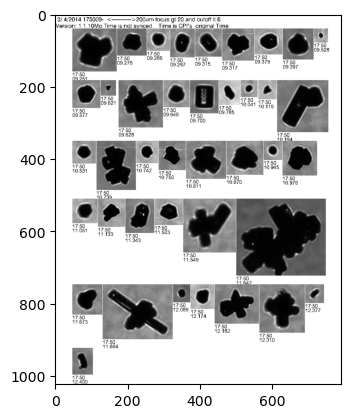

In [8]:
plt.imshow(img_gray, cmap='gray')

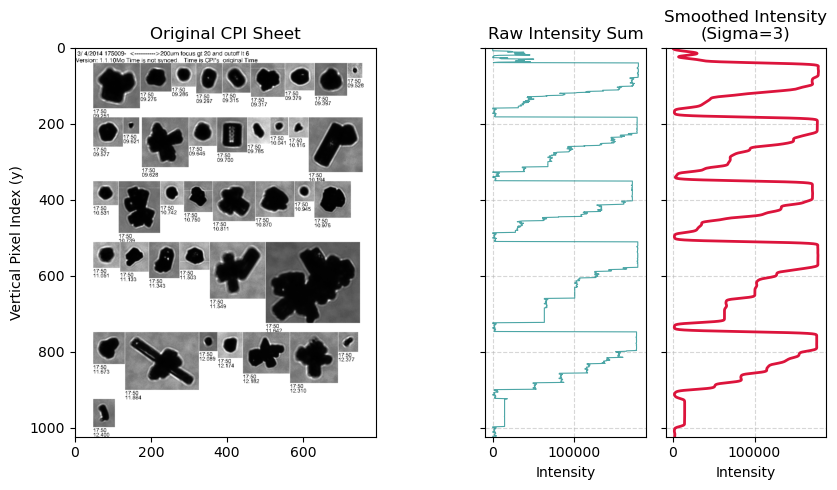

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# 1. Load and process image
# Assuming img_gray is already defined from your previous steps
_, binary = cv2.threshold(img_gray, 240, 255, cv2.THRESH_BINARY_INV)
row_sums = np.sum(binary, axis=1)

# 2. Generate Smoothed Version
# sigma=3 is usually a "sweet spot" for 1000px tall images
row_sums_smooth = gaussian_filter1d(row_sums, sigma=3)

# 3. Create Three-Panel Plot
# We use 3 subplots now: Image, Raw Intensity, Smoothed Intensity
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(9, 5), sharey=True, 
                                    gridspec_kw={'width_ratios': [3, 1, 1]})

# Panel 1: The Original Image
ax1.imshow(img_gray, cmap='gray')
ax1.set_title("Original CPI Sheet")
ax1.set_ylabel("Vertical Pixel Index (y)")

# Panel 2: The Raw Intensity Profile (The "Spiky" version)
y_indices = np.arange(len(row_sums))
ax2.plot(row_sums, y_indices, color='teal', linewidth=0.8, alpha=0.7)
ax2.set_title("Raw Intensity Sum")
ax2.set_xlabel("Intensity")
ax2.grid(True, linestyle='--', alpha=0.5)

# Panel 3: The Smoothed Intensity Profile (The "Clean" version)
ax3.plot(row_sums_smooth, y_indices, color='crimson', linewidth=2)
ax3.set_title("Smoothed Intensity\n(Sigma=3)")
ax3.set_xlabel("Intensity")
ax3.grid(True, linestyle='--', alpha=0.5)

# Ensure the Y-axis starts at 0 at the top for all plots
ax1.set_ylim(len(row_sums), 0) 

plt.tight_layout()
plt.show()

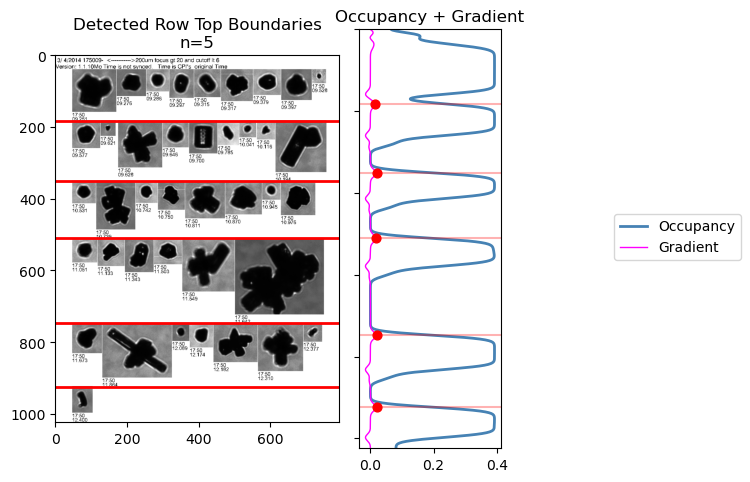

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

# ============================================================
# 0. Ensure grayscale
# ============================================================

if len(img.shape) == 3:
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
else:
    img_gray = img.copy()

# ============================================================
# 1. Foreground occupancy signal
# ============================================================

_, binary = cv2.threshold(
    img_gray,
    245,
    1,
    cv2.THRESH_BINARY_INV
)

# Use only leftmost 10% of image
h, w = binary.shape
left_width = int(w * 0.10)
binary_left = binary[:, :left_width]

# Foreground occupancy using only left region
row_signal = binary_left.mean(axis=1).astype(np.float32)

# Smooth
row_signal_smooth = gaussian_filter1d(
    row_signal,
    sigma=8
)

# # 1D signal: foreground fraction per row
# row_signal = binary.mean(axis=1).astype(np.float32)

# # Smooth
# row_signal_smooth = gaussian_filter1d(
#     row_signal,
#     sigma=8
# )

# ============================================================
# 2. First derivative
# ============================================================

gradient = np.diff(row_signal_smooth)

# Restore original length
gradient = np.insert(gradient, 0, 0)

# ============================================================
# 3. Detect row top boundaries
# ============================================================

top_edges, _ = find_peaks(
    gradient,
    prominence=0.02,
    distance=60
)

# ============================================================
# 4. Visualization
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(6, 5),
    sharey=True,
    gridspec_kw={"width_ratios": [2, 1]}
)

# ------------------------------------------------------------
# LEFT: image + boundaries
# ------------------------------------------------------------

ax1.imshow(img_gray, cmap="gray")

for y in top_edges:
    ax1.axhline(
        y=y,
        color="red",
        linewidth=2
    )

ax1.set_title(
    f"Detected Row Top Boundaries\nn={len(top_edges)}"
)

ax1.set_ylim(len(row_signal), 0)

# ------------------------------------------------------------
# RIGHT: signals
# ------------------------------------------------------------

y_axis = np.arange(len(row_signal))

ax2.plot(
    row_signal_smooth,
    y_axis,
    color="steelblue",
    linewidth=2,
    label="Occupancy"
)

ax2.plot(
    gradient,
    y_axis,
    color="magenta",
    linewidth=1,
    label="Gradient"
)

ax2.scatter(
    gradient[top_edges],
    top_edges,
    color="red",
    s=40,
    zorder=5
)

for y in top_edges:
    ax2.axhline(
        y=y,
        color="red",
        alpha=0.3
    )

ax2.set_title("Occupancy + Gradient")

fig.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

Alternative method using the sharp increase of the raw intensity signals.

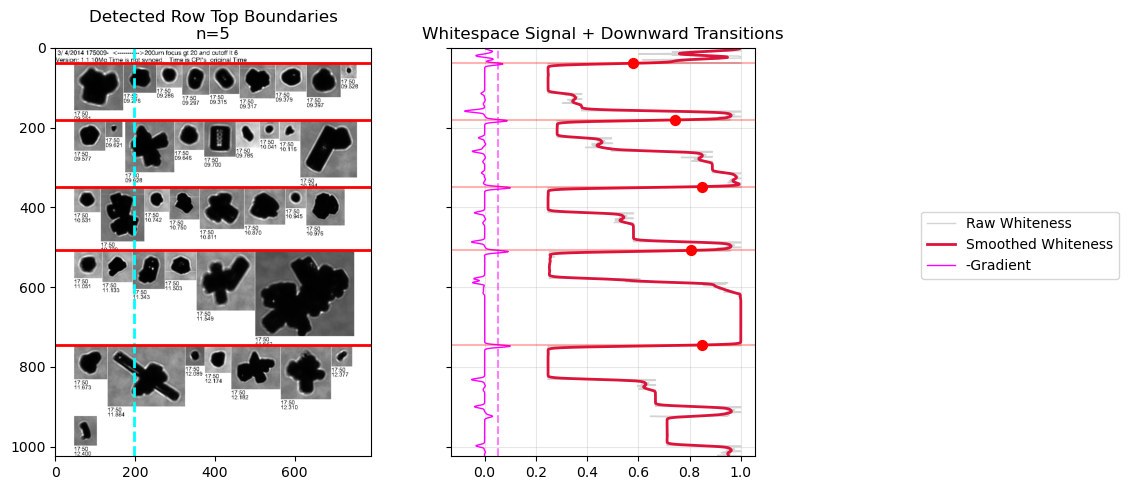

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ============================================================
# 0. Ensure grayscale
# ============================================================

if len(img.shape) == 3:
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
else:
    img_gray = img.copy()

# ============================================================
# 1. Analyze only left portion of sheet
# ============================================================

h, w = img_gray.shape

left_width = int(w * 0.25)

img_left = img_gray[:, :left_width]

# ============================================================
# 2. Horizontal whiteness signal
# ============================================================

# White pixels
white_mask = img_left > 245

# Fraction of row that is white
# Separator bands should appear highly white

row_signal = white_mask.mean(axis=1).astype(np.float32)

# Smooth vertically
row_signal_smooth = gaussian_filter1d(
    row_signal,
    sigma=3
)

# ============================================================
# 3. Compute downward transitions
# ============================================================

gradient = np.diff(row_signal_smooth)

# Restore original length
gradient = np.insert(gradient, 0, 0)

# Large positive values here mean:
# "whiteness rapidly decreased"

neg_gradient = -gradient

# ============================================================
# 4. Detect candidate row boundaries
# ============================================================

# Strong downward transitions

grad_thresh = np.percentile(
    neg_gradient,
    97
)

candidate_idx = np.where(
    neg_gradient > grad_thresh
)[0]

# ============================================================
# 5. Validate candidates
# ============================================================

top_edges = []

pre_window = 20
post_window = 20

min_distance = 120

for y in candidate_idx:

    # --------------------------------------------
    # Skip edges
    # --------------------------------------------

    if y < pre_window:
        continue

    if y + post_window >= h:
        continue

    # --------------------------------------------
    # Local regions
    # --------------------------------------------

    pre_region = row_signal_smooth[
        y - pre_window : y
    ]

    post_region = row_signal_smooth[
        y : y + post_window
    ]

    pre_mean = np.mean(pre_region)

    post_mean = np.mean(post_region)

    # --------------------------------------------
    # Relative drop magnitude
    # --------------------------------------------

    drop = pre_mean - post_mean

    # Require:
    #
    # 1. meaningful local drop
    # 2. strong derivative
    #

    if drop > 0.10:

        if (
            len(top_edges) == 0
            or
            y - top_edges[-1] > min_distance
        ):
            top_edges.append(y)

top_edges = np.array(
    top_edges,
    dtype=int
)

# ============================================================
# 6. Visualization
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(10, 5),
    sharey=True,
    gridspec_kw={"width_ratios": [2, 1]}
)

# ------------------------------------------------------------
# LEFT: image + detected boundaries
# ------------------------------------------------------------

ax1.imshow(img_gray, cmap="gray")

# Show analyzed region

ax1.axvline(
    x=left_width,
    color="cyan",
    linestyle="--",
    linewidth=2
)

# Draw boundaries

for y in top_edges:

    ax1.axhline(
        y=y,
        color="red",
        linewidth=2
    )

ax1.set_title(
    f"Detected Row Top Boundaries\nn={len(top_edges)}"
)

ax1.set_ylim(h, 0)

# ------------------------------------------------------------
# RIGHT: signal visualization
# ------------------------------------------------------------

y_axis = np.arange(h)

# Raw signal

ax2.plot(
    row_signal,
    y_axis,
    color="lightgray",
    linewidth=1,
    label="Raw Whiteness"
)

# Smoothed signal

ax2.plot(
    row_signal_smooth,
    y_axis,
    color="crimson",
    linewidth=2,
    label="Smoothed Whiteness"
)

# Negative derivative

ax2.plot(
    neg_gradient,
    y_axis,
    color="magenta",
    linewidth=1,
    label="-Gradient"
)

# Detection markers

ax2.scatter(
    row_signal_smooth[top_edges],
    top_edges,
    color="red",
    s=50,
    zorder=5
)

# Horizontal guide lines

for y in top_edges:

    ax2.axhline(
        y=y,
        color="red",
        alpha=0.3
    )

# Threshold line

ax2.axvline(
    grad_thresh,
    color="magenta",
    linestyle="--",
    alpha=0.5
)

ax2.set_title(
    "Whitespace Signal + Downward Transitions"
)

ax2.grid(alpha=0.3)

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------

fig.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.88, 1])

plt.show()

# Try using only the intensity along the vertical transect

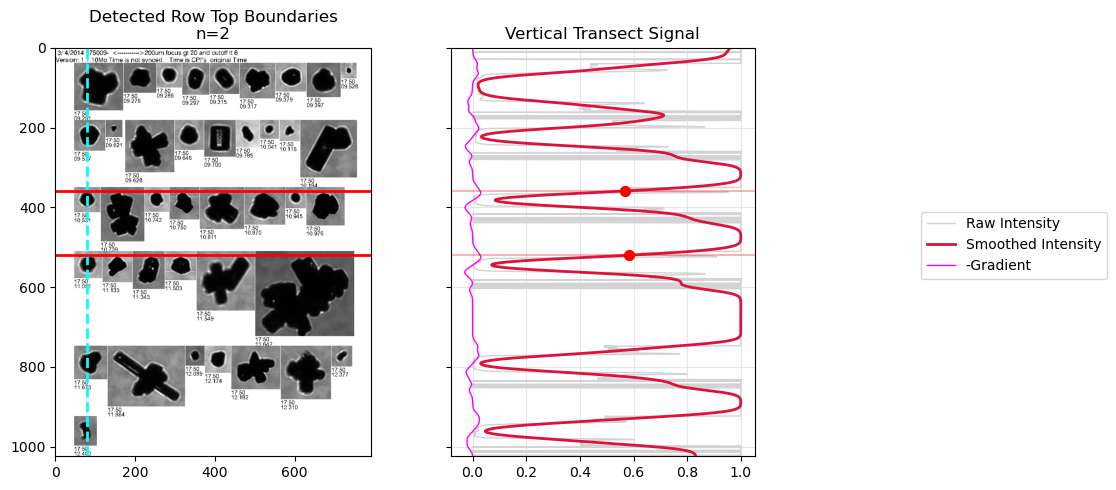

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ============================================================
# 0. Ensure grayscale
# ============================================================

if len(img.shape) == 3:
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
else:
    img_gray = img.copy()

h, w = img_gray.shape

# ============================================================
# 1. Choose vertical transect
# ============================================================

# Example:
# use x = 10% of image width

x_transect = int(w * 0.10)

# Extract vertical intensity profile

row_signal = img_gray[:, x_transect].astype(np.float32)

# Normalize to [0,1]

row_signal /= 255.0

# ============================================================
# 2. Smooth signal
# ============================================================

row_signal_smooth = gaussian_filter1d(
    row_signal,
    sigma=10
)

# ============================================================
# 3. Compute downward transitions
# ============================================================

gradient = np.diff(row_signal_smooth)

gradient = np.insert(gradient, 0, 0)

# Large positive values indicate:
# bright -> dark transition

neg_gradient = -gradient

# ============================================================
# 4. Detect candidate boundaries
# ============================================================

grad_thresh = np.percentile(
    neg_gradient,
    98
)

candidate_idx = np.where(
    neg_gradient > grad_thresh
)[0]

# ============================================================
# 5. Validate candidates
# ============================================================

top_edges = []

pre_window = 20
post_window = 20

min_distance = 120

for y in candidate_idx:

    if y < pre_window:
        continue

    if y + post_window >= h:
        continue

    # --------------------------------------------
    # Local regions
    # --------------------------------------------

    pre_region = row_signal_smooth[
        y - pre_window : y
    ]

    post_region = row_signal_smooth[
        y : y + post_window
    ]

    pre_mean = np.mean(pre_region)

    post_mean = np.mean(post_region)

    drop = pre_mean - post_mean

    # Require substantial local decrease

    if drop > 0.15:

        if (
            len(top_edges) == 0
            or
            y - top_edges[-1] > min_distance
        ):
            top_edges.append(y)

top_edges = np.array(
    top_edges,
    dtype=int
)

# ============================================================
# 6. Visualization
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(10, 5),
    sharey=True,
    gridspec_kw={"width_ratios": [2, 1]}
)

# ------------------------------------------------------------
# LEFT: image + boundaries
# ------------------------------------------------------------

ax1.imshow(img_gray, cmap="gray")

# Show transect

ax1.axvline(
    x=x_transect,
    color="cyan",
    linestyle="--",
    linewidth=2
)

# Draw boundaries

for y in top_edges:

    ax1.axhline(
        y=y,
        color="red",
        linewidth=2
    )

ax1.set_title(
    f"Detected Row Top Boundaries\nn={len(top_edges)}"
)

ax1.set_ylim(h, 0)

# ------------------------------------------------------------
# RIGHT: signal visualization
# ------------------------------------------------------------

y_axis = np.arange(h)

# Raw signal

ax2.plot(
    row_signal,
    y_axis,
    color="lightgray",
    linewidth=1,
    label="Raw Intensity"
)

# Smoothed signal

ax2.plot(
    row_signal_smooth,
    y_axis,
    color="crimson",
    linewidth=2,
    label="Smoothed Intensity"
)

# Downward transitions

ax2.plot(
    neg_gradient,
    y_axis,
    color="magenta",
    linewidth=1,
    label="-Gradient"
)

# Detection markers

ax2.scatter(
    row_signal_smooth[top_edges],
    top_edges,
    color="red",
    s=50,
    zorder=5
)

# Horizontal lines

for y in top_edges:

    ax2.axhline(
        y=y,
        color="red",
        alpha=0.3
    )

ax2.set_title(
    "Vertical Transect Signal"
)

ax2.grid(alpha=0.3)

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------

fig.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.88, 1])

plt.show()

### horizontal segmentation for each row

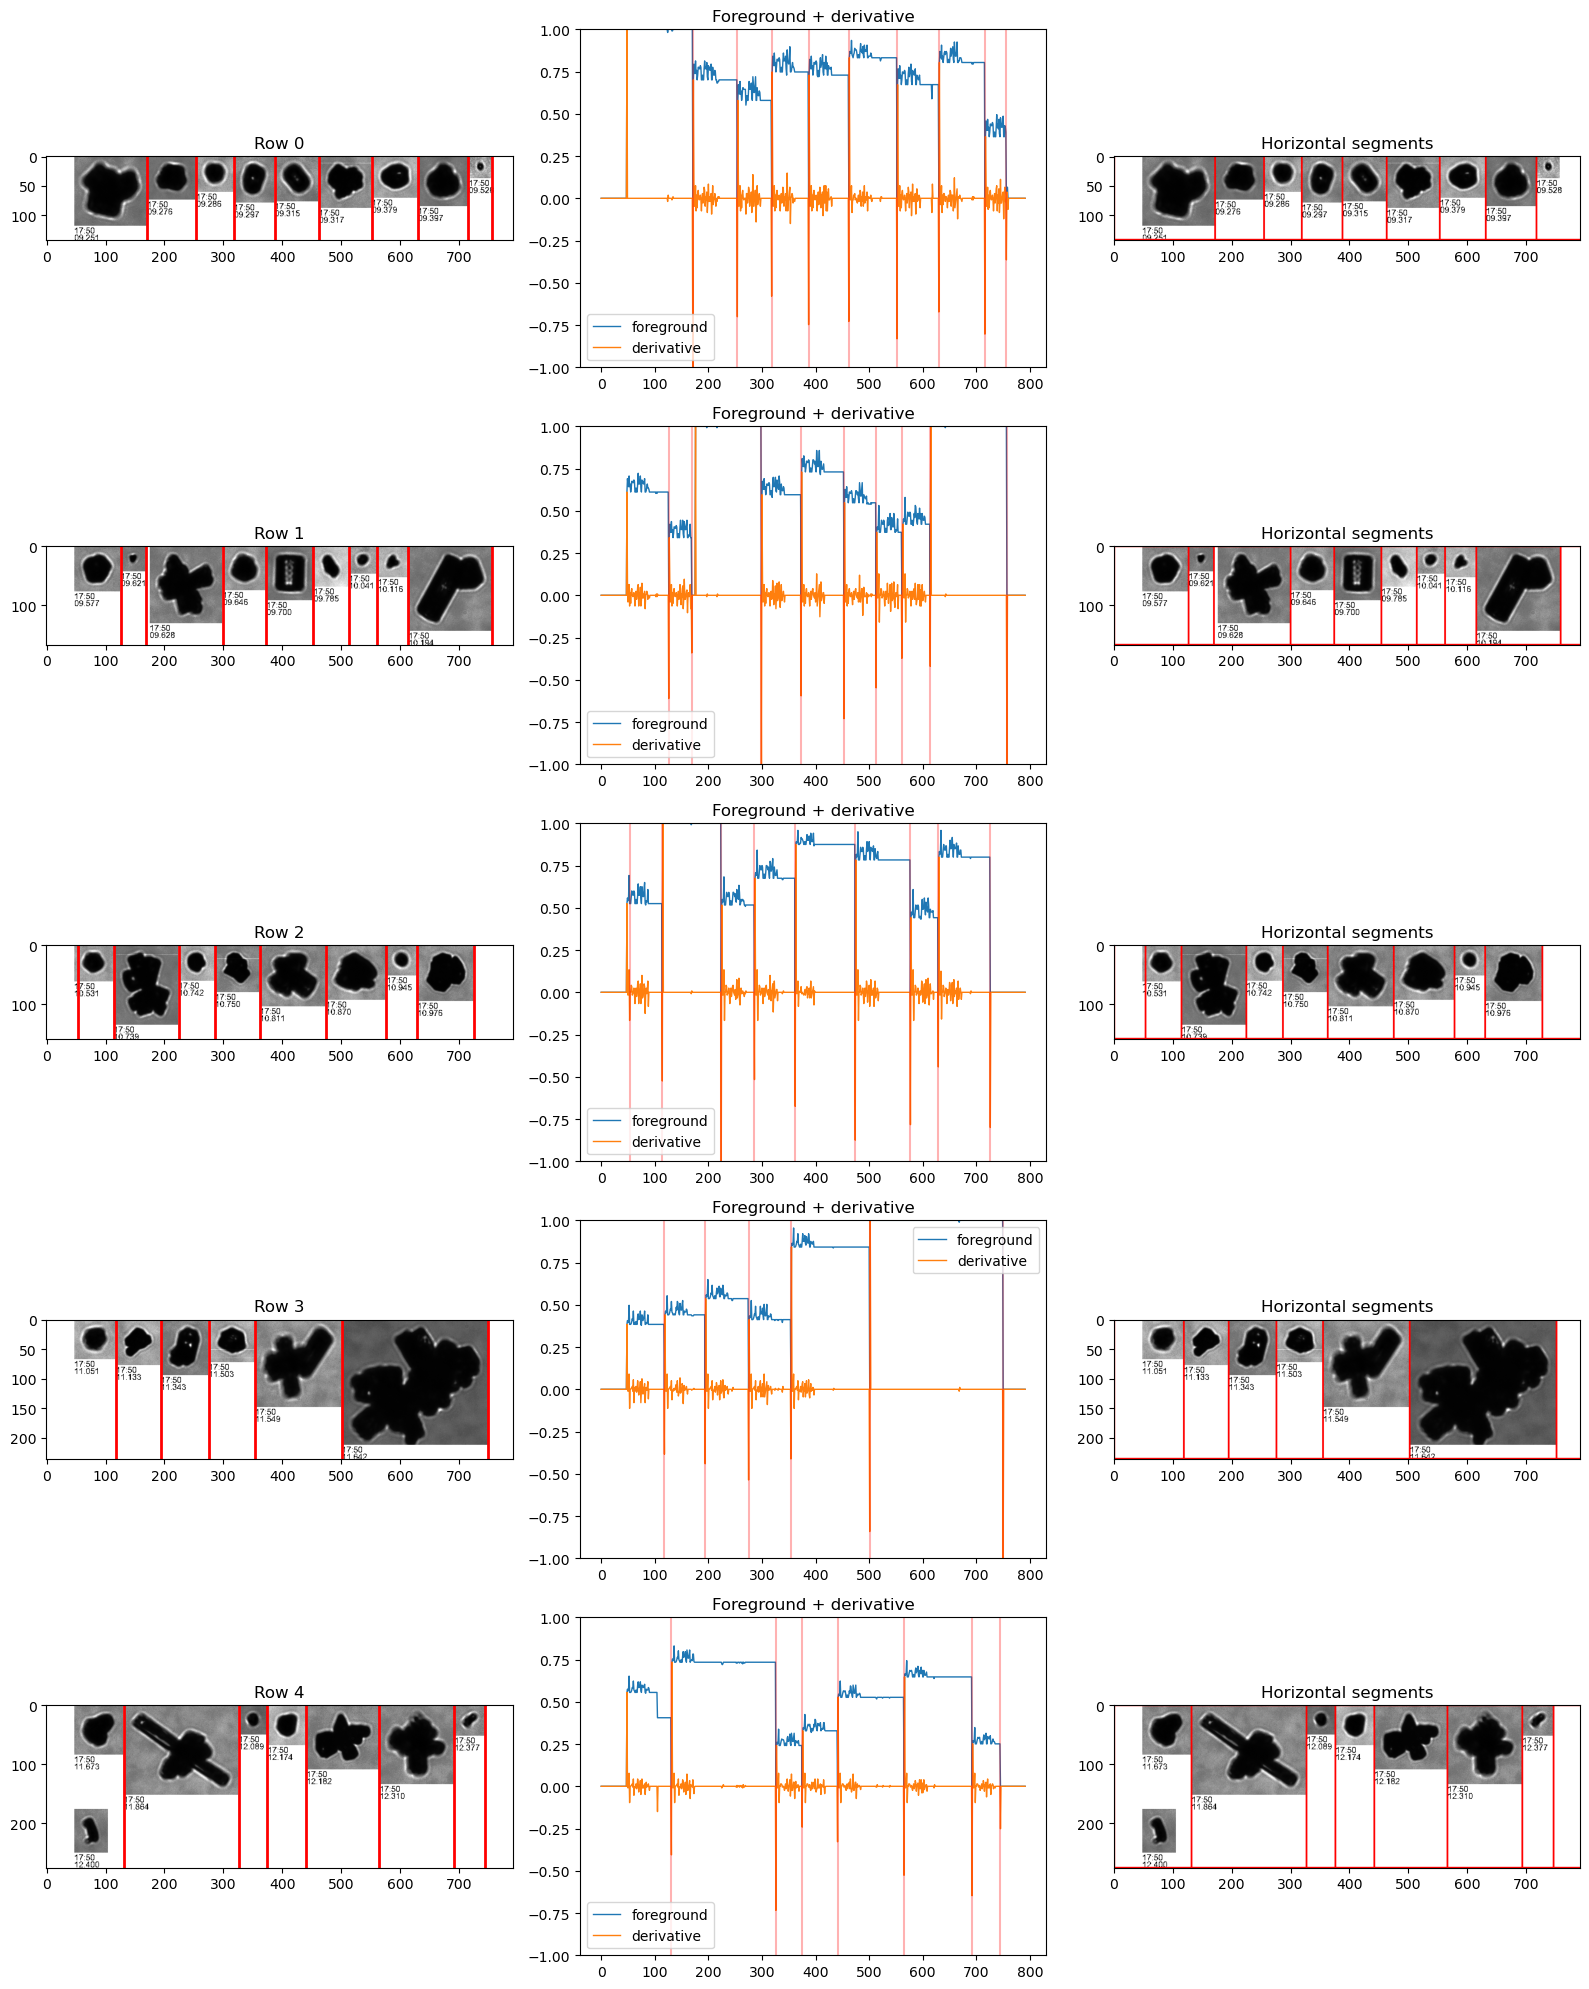

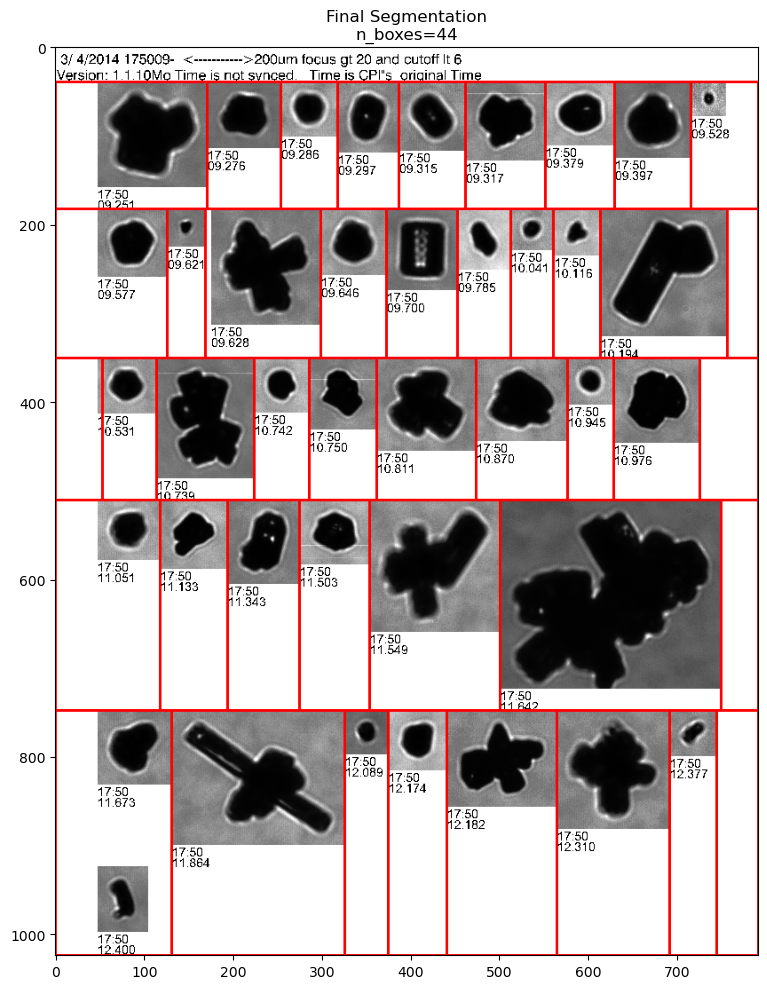

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

# ============================================================
# 0. Ensure grayscale
# ============================================================

if len(img.shape) == 3:
    img_gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )
else:
    img_gray = img.copy()

H, W = img_gray.shape

# ============================================================
# 1. FOREGROUND MASK
# ============================================================

_, binary = cv2.threshold(
    img_gray,
    245,
    1,
    cv2.THRESH_BINARY_INV
)

# ============================================================
# 2. VERTICAL ROW DETECTION
#
# Ignore top metadata/header region
# ============================================================

header_cutoff = 40

# Only analyze below header
binary_rows = binary[
    header_cutoff:,
    :
]

# ------------------------------------------------------------
# Foreground occupancy per row
# ------------------------------------------------------------

row_signal = (
    binary_rows.mean(axis=1)
    .astype(np.float32)
)

# ------------------------------------------------------------
# Smooth
# ------------------------------------------------------------

row_signal_smooth = gaussian_filter1d(
    row_signal,
    sigma=8
)

# ------------------------------------------------------------
# Gradient
# ------------------------------------------------------------

gradient = np.diff(
    row_signal_smooth
)

gradient = np.insert(
    gradient,
    0,
    0
)

# ------------------------------------------------------------
# Detect row starts
# ------------------------------------------------------------

top_edges, _ = find_peaks(
    gradient,
    prominence=0.02,
    distance=80
)

# Convert back to full-image coordinates
top_edges = (
    top_edges + header_cutoff
)

# ------------------------------------------------------------
# Build row boundaries
# ------------------------------------------------------------

row_boundaries = (
    [header_cutoff]
    +
    sorted(top_edges.tolist())
    +
    [H]
)

# ============================================================
# REMOVE TINY ROWS
# ============================================================

filtered_rows = [row_boundaries[0]]

for y in row_boundaries[1:]:

    if y - filtered_rows[-1] > 60:

        filtered_rows.append(y)

row_boundaries = filtered_rows

# ============================================================
# 3. HORIZONTAL SEGMENTATION
# ============================================================

all_boxes = []

fig, axes = plt.subplots(
    len(row_boundaries) - 1,
    3,
    figsize=(16, 4 * (len(row_boundaries) - 1))
)

if len(row_boundaries) - 1 == 1:

    axes = np.expand_dims(
        axes,
        axis=0
    )

for i in range(len(row_boundaries) - 1):

    y0 = row_boundaries[i]
    y1 = row_boundaries[i + 1]

    row_img = img_gray[y0:y1]

    row_bin = binary[
        y0:y1,
        :
    ]

    # ========================================================
    # REMOVE LOWER TEXT REGION
    #
    # timestamps contaminate signal
    # ========================================================

    signal_h = int(
        row_img.shape[0] * 0.75
    )

    row_bin_signal = row_bin[:signal_h]

    # ========================================================
    # FOREGROUND SIGNAL
    # ========================================================

    fg_counts = row_bin_signal.sum(axis=0)

    fg_signal = (
        fg_counts / row_bin_signal.shape[0]
    )

    # ========================================================
    # SMOOTH SIGNAL
    # ========================================================

    fg_signal_smooth = cv2.GaussianBlur(
        fg_signal.reshape(1, -1),
        (1, 11),
        0
    ).flatten()

    # ========================================================
    # DERIVATIVE
    # ========================================================

    d_fg = np.diff(
        fg_signal_smooth
    )

    d_fg = np.insert(
        d_fg,
        0,
        0
    )

    # ========================================================
    # DETECT LEFT EDGES OF CRYSTALS
    #
    # strong negative transitions only
    # ========================================================

    left_edge_mask = (
        d_fg < -0.15
    )

    left_edge_cols = np.where(
        left_edge_mask
    )[0]

    # ========================================================
    # COLLAPSE NEARBY EDGES
    # ========================================================

    separator_cols = []

    for x in left_edge_cols:

        if (
            len(separator_cols) == 0
            or
            x - separator_cols[-1] > 35
        ):

            separator_cols.append(x)

    separator_cols = np.array(
        separator_cols
    )

    # ========================================================
    # BUILD SEGMENTS
    # ========================================================

    x_boundaries = [0]

    for x in separator_cols:

        if x - x_boundaries[-1] > 40:

            x_boundaries.append(x)

    x_boundaries.append(W)

    # ========================================================
    # SAVE BOXES
    # ========================================================

    for j in range(len(x_boundaries) - 1):

        x0 = x_boundaries[j]
        x1 = x_boundaries[j + 1]

        all_boxes.append(
            (x0, y0, x1, y1)
        )

    # ========================================================
    # VISUALIZATION
    # ========================================================

    ax_img = axes[i, 0]
    ax_sig = axes[i, 1]
    ax_seg = axes[i, 2]

    # --------------------------------------------------------
    # LEFT: row image
    # --------------------------------------------------------

    ax_img.imshow(
        row_img,
        cmap="gray"
    )

    for x in separator_cols:

        ax_img.axvline(
            x=x,
            color="red",
            linewidth=2
        )

    ax_img.set_title(
        f"Row {i}"
    )

    # --------------------------------------------------------
    # MIDDLE: foreground + derivative
    # --------------------------------------------------------

    x_axis = np.arange(W)

    ax_sig.plot(
        x_axis,
        fg_signal_smooth,
        linewidth=1,
        label="foreground"
    )

    ax_sig.plot(
        x_axis,
        d_fg,
        linewidth=1,
        label="derivative"
    )

    for x in separator_cols:

        ax_sig.axvline(
            x=x,
            color="red",
            alpha=0.3
        )

    ax_sig.set_ylim(-1, 1)

    ax_sig.set_title(
        "Foreground + derivative"
    )

    ax_sig.legend()

    # --------------------------------------------------------
    # RIGHT: segmentation
    # --------------------------------------------------------

    overlay = cv2.cvtColor(
        row_img,
        cv2.COLOR_GRAY2RGB
    )

    for x0, x1 in zip(
        x_boundaries[:-1],
        x_boundaries[1:]
    ):

        cv2.rectangle(
            overlay,
            (x0, 0),
            (
                x1,
                row_img.shape[0] - 1
            ),
            (255, 0, 0),
            2
        )

    ax_seg.imshow(overlay)

    ax_seg.set_title(
        "Horizontal segments"
    )

plt.tight_layout()
plt.show()

# ============================================================
# FINAL VISUALIZATION
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 10)
)

overlay = cv2.cvtColor(
    img_gray,
    cv2.COLOR_GRAY2RGB
)

for x0, y0, x1, y1 in all_boxes:

    cv2.rectangle(
        overlay,
        (x0, y0),
        (x1, y1),
        (255, 0, 0),
        2
    )

ax.imshow(overlay)

ax.set_title(
    f"Final Segmentation\nn_boxes={len(all_boxes)}"
)

plt.tight_layout()
plt.show()

# Visually inspect sheets samples from all campaigns

- ./MC3E/sheets
- ./ARM/sheets
- ./MPACE/sheets
- ./IPHEX/sheets
- ./AIRS_II/sheets
- ./ICE_L/sheets
- ./CRYSTAL_FACE_NASA/sheets
- ./MACPEX/sheets
- ./MIDCIX/sheets
- ./ISDAC/sheets
- ./ATTREX/sheets
- ./OLYMPEX/sheets
- ./CRYSTAL_FACE_UND/sheets

In [35]:
from pathlib import Path
import random
import shutil

# =========================================================
# Configuration
# =========================================================

campaigns_root = Path(
    "/home/vanessa/hulk/cocpit/cpi_data/campaigns"
)

output_root = Path("../data/sample_sheets")

N_samples = 10

# =========================================================
# Campaign sheet directories
# =========================================================

campaign_sheet_dirs = [
    "./MC3E/sheets",
    "./ARM/sheets",
    "./MPACE/sheets",
    "./IPHEX/sheets",
    "./AIRS_II/sheets",
    "./ICE_L/sheets",
    "./CRYSTAL_FACE_NASA/sheets",
    "./MACPEX/sheets",
    "./MIDCIX/sheets",
    "./ISDAC/sheets",
    "./ATTREX/sheets",
    "./OLYMPEX/sheets",
    "./CRYSTAL_FACE_UND/sheets",
]

# =========================================================
# Main loop
# =========================================================

for rel_path in campaign_sheet_dirs:

    sheets_dir = campaigns_root / rel_path

    campaign_name = sheets_dir.parent.name

    print("=" * 60)
    print(f"Campaign: {campaign_name}")

    # -----------------------------------------------------
    # Output directory
    # -----------------------------------------------------

    campaign_output_dir = output_root / campaign_name

    campaign_output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    # -----------------------------------------------------
    # Gather files
    # -----------------------------------------------------

    files = [
        f for f in sheets_dir.iterdir()
        if f.is_file()
    ]

    if len(files) == 0:
        print("No files found.")
        continue

    # -----------------------------------------------------
    # Random sample
    # -----------------------------------------------------

    sample_count = min(N_samples, len(files))

    sampled_files = random.sample(
        files,
        sample_count
    )

    print(f"Copying {sample_count} files...")

    # -----------------------------------------------------
    # Copy files
    # -----------------------------------------------------

    for src_file in sampled_files:

        dst_file = campaign_output_dir / src_file.name

        shutil.copy2(
            src_file,
            dst_file
        )

    print(f"Saved to:")
    print(campaign_output_dir)
    print()

print("=" * 60)
print("Done.")

Campaign: MC3E
Copying 10 files...
Saved to:
../data/sample_sheets/MC3E

Campaign: ARM
Copying 10 files...
Saved to:
../data/sample_sheets/ARM

Campaign: MPACE
Copying 10 files...
Saved to:
../data/sample_sheets/MPACE

Campaign: IPHEX
Copying 10 files...
Saved to:
../data/sample_sheets/IPHEX

Campaign: AIRS_II
Copying 10 files...
Saved to:
../data/sample_sheets/AIRS_II

Campaign: ICE_L
Copying 10 files...
Saved to:
../data/sample_sheets/ICE_L

Campaign: CRYSTAL_FACE_NASA
Copying 10 files...
Saved to:
../data/sample_sheets/CRYSTAL_FACE_NASA

Campaign: MACPEX
Copying 10 files...
Saved to:
../data/sample_sheets/MACPEX

Campaign: MIDCIX
Copying 10 files...
Saved to:
../data/sample_sheets/MIDCIX

Campaign: ISDAC
Copying 10 files...
Saved to:
../data/sample_sheets/ISDAC

Campaign: ATTREX
Copying 10 files...
Saved to:
../data/sample_sheets/ATTREX

Campaign: OLYMPEX
Copying 10 files...
Saved to:
../data/sample_sheets/OLYMPEX

Campaign: CRYSTAL_FACE_UND
Copying 10 files...
Saved to:
../data/sam

# Notes

- Most promising route is whitespace detection for segmentation, but ran into various issues
- Some prominent issues:
    - inconsistent annotation text, sometimes overlapping CPI images
    - inconsistent layout between campaigns 
    - OCR does not work well to segment text 
    - header height is not consistent
- CPI binary files should be stream of single images (?)

As of May 13, 2026:
- Use the existing segmented single images from Vanessa's code
- Can refine the dataset later after publishing initial paper as a v2